# Overview

This project creates and tests a RAG system as a proof of concept.

The overall scenario is as follows:

You work at a tech company that is looking for new ways to organize their question answering and search capabilities to accelerate both engineering activity and the marketing team's production.  Founded in 2018, your company has grown rapidly to 300 engineers across distributed teams in San Francisco, Austin, and remotely, plus a 40-person marketing organization split between demand generation, content, product marketing, and customer education. The company also wants to roll out new GenAI-based products, so a lot of the questions will center around Generative AI concepts. Product releases are done quarterly.

As a Senior ML Engineer on your company's newly formed AI Infrastructure team, you've been tapped to lead a four-week proof-of-concept (mini-POC) evaluating whether a Retrieval-Augmented Generation (RAG) system could address the challenges and support both the engineering and marketing organizations. Your executive sponsor is the VP of Engineering, who has secured buy-in from the CMO and allocated a small budget for this exploratory work.


So overall, the goals of this project are for you to:

*  Implement a RAG system using LangChain
*  Be able to formulate metric(s) that you may want to choose as your evaluation of the degree to which your system replicates gold answers (labeled data) that we will provide.
* Try out various hyper-parameters, settings, and other techniques to see which configuration works the best (given your chosen metric)  
* Write a comprehensive evaluation report, which also includes risks and limitations (and a lot more)


The notebook is organized as follows:

1. Set-Up

2. Base RAG components

    We will provide a base LangChain-based framework for you to use as inspiration for your RAG system. The components we’ll need include:  

      - 2.1 Text Embeddings    
      - 2.2 Text Chunking   
      - 2.3 The Vector DB & Semantic Search  
      - 2.4 The Language Model   
      - 2.5 Testing the LLM in a LangChain Chain   
      - 2.6. Setting up a simple RAG Chain     


3. Using RAG  

    We will provide a collection of documents for you to use for your RAG system. We will also provide a test of questions with "Gold" answers.  

      - 3.1 Loading of Data  
      - 3.2 Test Queries
      - 3.3 Running Your Implemented Model(s) and Your Experiments


4.  Evaluations

    Here, you will develop your strategy and conduct your evaluations of your RAG system

      - 4.1 Metrics
      - 4.2 Best Runs with your Metrics


5. Final Results

    In this section, you will answer some questions and provide a link to your final report

      - 5.1 Model Specifications
      - 5.2 Three Test Questions (and Results)
      - 5.3 Five Other Questions
      - 5.4 Link To Your 4-5 Page Final POC Report and Recommendation

## 1. Setup

We will first install a number of libraries and import what we will need.





In [1]:
%%capture
!pip install -qU langchain langchain-community langchain-huggingface langchain-qdrant
!pip install -qU qdrant-client sentence-transformers arxiv pymupdf
!pip install -qU transformers accelerate bitsandbytes

!pip install -q -U xmltodict

!pip install -q -U cohere

!pip install -q -U langchain-cohere

!pip install -q -U wikipedia


In [2]:
#In case we want to know our installed transformers library version
!pip list | grep transformers
!pip list | grep accelerate
!pip list | grep langchain
!pip list | grep huggingface

sentence-transformers                    5.4.0
transformers                             5.5.3
accelerate                               1.13.0
langchain                                1.2.15
langchain-classic                        1.0.3
langchain-cohere                         0.5.0
langchain-community                      0.4.1
langchain-core                           1.2.23
langchain-huggingface                    1.2.1
langchain-qdrant                         1.1.0
langchain-text-splitters                 1.1.1
huggingface_hub                          1.8.0
langchain-huggingface                    1.2.1


In [3]:
%%capture
!pip install bert-score

In [4]:
import os
import numpy as np
import time
import locale
from google.colab import userdata

# IMPORTANT: Add your Hugging Face token to Colab's Secrets (the key icon on the left panel)
# and name it 'HF_TOKEN', or replace the line below with os.environ["HF_TOKEN"] = "your_token"
os.environ["HF_TOKEN"] = userdata.get('HF_TOKEN')

import langchain
from langchain_community.document_loaders import ArxivLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings, HuggingFacePipeline
from langchain_qdrant import QdrantVectorStore

from qdrant_client import QdrantClient
from qdrant_client.http.models import Distance, VectorParams
from langchain_community.vectorstores import Qdrant, FAISS
from langchain_core.prompts import PromptTemplate
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser

from langchain_community.document_loaders import ArxivLoader
from langchain_community.document_loaders import PyMuPDFLoader

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline, BitsAndBytesConfig


from langchain_cohere import ChatCohere

import torch.nn.functional as F
from torch import Tensor
from transformers import AutoModel

import bs4
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.document_loaders import TextLoader
from langchain_community.document_loaders import WikipediaLoader

# additional library
import pandas as pd
import random
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
from bert_score import scorer
from google.colab import drive, userdata
import pickle
from operator import itemgetter
import time
from pprint import pprint

In [5]:
#import langchain
print(langchain.__version__)

1.2.15


In [6]:
locale.getpreferredencoding = lambda: "UTF-8"

In [7]:
%%capture
!pip install -U sentence_transformers

Add your keys from the secret store (do **NOT** print them out or leave them exposed as plaintext in your notebook!):

In [8]:
COHERE_API_KEY = userdata.get('COHERE_API_KEY')

## 2. Building the Components of our RAG System

Let us introduce and test the base components of our RAG system. We will largely use the Hugging Face and LangChain libraries.



### 2.1 The Embedding Model

We will need to represent text (pieces) as vectors. For this, we will use the [sentence_transformer](https://sbert.net/docs/sentence_transformer/pretrained_models.html) architecture.



**NOTE:** The embedding models you can use are: 'all-mpnet-base-v2', 'all-MiniLM-L12-v2', 'multi-qa-mpnet-base-dot-v1', 'all-distilroberta-v1', and 'multi-qa-distilbert-cos-v1 '



In [ ]:
%%capture
base_embeddings = HuggingFaceEmbeddings(model_name="multi-qa-mpnet-base-dot-v1") # 'all-mpnet-base-v2', 'all-MiniLM-L12-v2', 'multi-qa-mpnet-base-dot-v1', 'all-distilroberta-v1', and 'multi-qa-distilbert-cos-v1 '

MPNetModel LOAD REPORT from: sentence-transformers/multi-qa-mpnet-base-dot-v1
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
text = "This is a test document."
query_result = base_embeddings.embed_query(text)
print(f'Embedding dimension: {len(query_result)}')

doc_result = base_embeddings.embed_documents(["Germany won the World Cup 4 times.", "This is a training document."])
len(doc_result)

Embedding dimension: 768


2

Do those dimensions look correct?

Now lets see if the embedding model is working as we want.  Ideally our embeddings go beyond shared words and capture the underlying meaning.

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

#Let's see how well our embeddng model works
similarity = cosine_similarity([query_result], doc_result)[0]

similarity

array([0.21410203, 0.83639483])

That's how you should define your embedding models.

Next, we turn to text chunks.

### 2.2. Loading and Chunking Texts

We first need to load the documents. Here is an example:

In [ ]:
loader = WebBaseLoader(
    web_paths=("https://lilianweng.github.io/posts/2023-06-23-agent/",),
    bs_kwargs=dict(
        parse_only=bs4.SoupStrainer(
            class_=("post-content", "post-title", "post-header")
        )
    ),
)

documents = loader.load()

We will need to split the  text in chunks that are 'suitable' as retrieval units. Let's for starters define a chunk size of 128 and have no overlap between the chunks:  


In [ ]:
text_splitter = RecursiveCharacterTextSplitter(chunk_size=128, chunk_overlap=0)
splits = text_splitter.split_documents(documents)
print('Number of splits/chunks: ', str(len(splits)))

Number of splits/chunks:  446


Ok, so it looks like we have now many splits (chunks) from one document. Here is how you can get the content:

In [ ]:
splits[39].page_content

'Self-reflection is a vital aspect that allows autonomous agents to improve iteratively by refining past action decisions and'

Perfect. Now we have the splits and embeddings. Next, the embeddings need to be stored in a vector db.

### 2.3 Storing the Embeddings of Chunks in Vectorstores

After loading and chunking the data, we need to save the vector representations of the chunks in a vectorstore. We will use Qdrant here for simplicity. We load the splits (structured chunks) and the embeddings:

In [ ]:
vectorstore = QdrantVectorStore.from_documents(splits,
    base_embeddings,
    location=":memory:",  # Local mode with in-memory storage only
    collection_name="test",
)
retriever = vectorstore.as_retriever()

The nice thing is that the vector store also does the similarity searches for us:

In [ ]:
query = "What is Chain of Thought doing?"
docs = vectorstore.similarity_search_by_vector(base_embeddings.embed_query(query)) # will rank the splits

In [ ]:
docs

[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', '_id': '204eedb7cdf0418fadc88df576cfc65e', '_collection_name': 'test'}, page_content='the model’s thinking process.'),
 Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', '_id': 'ff851ee2334540ae868d7272db7747e7', '_collection_name': 'test'}, page_content='[1] Wei et al. “Chain of thought prompting elicits reasoning in large language models.” NeurIPS 2022'),
 Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', '_id': 'de1ef3b65ddc414ea8fe27edd75e8fb8', '_collection_name': 'test'}, page_content='the problem into multiple thought steps and generates multiple thoughts per step, creating a tree structure. The search process'),
 Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', '_id': 'dac21104cb9448c686b9f2958fa1cbd4', '_collection_name': 'test'}, page_content='Chain of thought (CoT; Wei et al. 2022) has 

Looks good! We have an ordered list of documents that seem to relate to the question. That is what we need.

The last major component is the actual LLM.

### 2.4. The LLM

We will use one Open Source Model ("mistralai/Mistral-7B-Instruct-v0.3") and one Proprietery Model (Cohere) for our tests. Let's first set up the OS model:

In [ ]:
#Quantization config

quantization_config = BitsAndBytesConfig(
   load_in_4bit=True,
   bnb_4bit_quant_type="nf4",
   bnb_4bit_use_double_quant=True,
   bnb_4bit_compute_dtype=torch.bfloat16
)

In [ ]:
#%%capture

llm_mistral_model = AutoModelForCausalLM.from_pretrained(
    "mistralai/Mistral-7B-Instruct-v0.3",
    dtype=torch.float32,
    device_map='auto',
    quantization_config=quantization_config
)

llm_mistral_tokenizer = AutoTokenizer.from_pretrained("mistralai/Mistral-7B-Instruct-v0.3")

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

We use the model first to generate a Hugging Face pipeline. A pipeline simplifies the process of actually generating responses.

In [ ]:
mistral_pipe = pipeline(
    "text-generation",
    model=llm_mistral_model,
    tokenizer=llm_mistral_tokenizer,
    max_new_tokens=1000,
    temperature=0.6,
    top_p=0.95,
    do_sample=True,
    repetition_penalty=1.2
)
mistral_pipe.model.config.pad_token_id = mistral_pipe.model.config.eos_token_id

    # wrapping the Hugging Face pipeline into a LangChain object

Passing `generation_config` together with generation-related arguments=({'repetition_penalty', 'top_p', 'do_sample', 'temperature', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


Does it work?

In [ ]:
mistral_pipe("[INST]Give me a two-sentence story about an apple![/INST]")

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=1000) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'generated_text': '[INST]Give me a two-sentence story about an apple![/INST] In the heart of an ancient orchard, where every tree bore fruit unique to its age, one apple ripened under the moonlight, promising a taste like no other. A humble thief, enamored by legends of this mystical fruit, embarked on a daring nighttime heist, seeking adventure and the secret of the luminous apple.'}]

Reasonable!

We will also use a Cohere model, but will create this below as part of the LangChain framework.

### 2.5 Testing the LLM in a LangChain Chain

Chains will be defined and discussed in Week 10. In short, they are convenient programmatic ways to deal with 'chains' of actions that involve LLMs. For example, a list of events like 'here is a city name. Plug that city name into prompt template, then generate a story about that city. Lastly, format the model output as a string' can be easily handled by LangChain's Chain framework. In this case, the Chain would consist of the prompt template, the LLM, and the String Formatter. The parameter (the city in this case) will be provided at run time by invocation of the Chain. Let's test that.

To use a Hugging Face model in a LangChain environment, we need to wrap the model into a LangChain pipeline object:

In [ ]:
mistral_llm_lc = HuggingFacePipeline(pipeline=mistral_pipe)

Next, we need to define a template and create a corresponding prompt template that can take any questiion

In [ ]:
test_llm_template = """[INST] Give me a two-sentence story about an {object}! [/INST]"""
test_llm_prompt_template = PromptTemplate(template=test_llm_template, input_variables=["object"])



Let's define a Chain, a static flow of actions that (usually) involve at least a definition of the variables used in the chain, one or more templates, LLM step(s) and potentially other actions. This would be a chain that declares the variable 'object' to be expected when the chain is invoked, then inserts it into the template, and passes this to our mistral model pipeline (wrapped as a LangChain object):    

In [ ]:
test_llm_chain_short = (
    {"object": RunnablePassthrough()}
    | test_llm_prompt_template
    | mistral_llm_lc
)

In [ ]:
test_llm_chain_short.invoke('apple')

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=1000) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


'[INST] Give me a two-sentence story about an apple! [/INST] In the heart of an ancient forest, a solitary apple tree bloomed each year. One autumn, it bore a single, exceptionally radiant fruit that captured the attention and dreams of all who beheld its golden glow – a symbol of hope amidst the encroaching darkness.'

Works too. We will use this notation moving forward.

Next, how would we do this with a Cohere Chat Model instead of Mistral?

In [ ]:
cohere_chat_model = ChatCohere(cohere_api_key=COHERE_API_KEY)

This can be plugged straight into the Chain:

In [ ]:
test_cohere_llm_chain_short = (
    {"object": RunnablePassthrough()}
    | test_llm_prompt_template
    | cohere_chat_model
)

In [ ]:
test_cohere_llm_chain_short.invoke('apple')

AIMessage(content="A curious squirrel discovered a shiny red apple hanging from a branch, its sweet scent tempting him closer. With a quick leap, he claimed the fruit, savoring its crispness as he scampered away, unaware of the farmer's watchful eye.", additional_kwargs={'id': '42a549a6-22c4-474e-af70-4f34c272b6b2', 'finish_reason': 'COMPLETE', 'content': "A curious squirrel discovered a shiny red apple hanging from a branch, its sweet scent tempting him closer. With a quick leap, he claimed the fruit, savoring its crispness as he scampered away, unaware of the farmer's watchful eye.", 'token_count': {'input_tokens': 512.0, 'output_tokens': 52.0}}, response_metadata={'id': '42a549a6-22c4-474e-af70-4f34c272b6b2', 'finish_reason': 'COMPLETE', 'content': "A curious squirrel discovered a shiny red apple hanging from a branch, its sweet scent tempting him closer. With a quick leap, he claimed the fruit, savoring its crispness as he scampered away, unaware of the farmer's watchful eye.", 'to

Works! (Note: you may want to review the format of the template. The one we used here is the one from Mistral, and the format may or may not be optimal for Cohere.)

How can we get the output formatting under control? We can add a String Formatter to the chain:


In [ ]:
output_parser = StrOutputParser()

test_cohere_llm_chain_short_formatted = (
    {"object": RunnablePassthrough()}
    | test_llm_prompt_template
    | cohere_chat_model
    | output_parser
)

test_cohere_llm_chain_short_formatted.invoke('apple')

'A curious squirrel discovered a shiny red apple nestled in the grass, its sweet scent irresistible. With a quick scamper up the nearest tree, the squirrel enjoyed its prize, savoring each juicy bite as the autumn sun warmed its fur.'

### 2.6 Setting Up a Simple RAG Chain

For RAG, we will follow the same approach. Except... you will **later** need to change the chain to include the retrieval step.

We first do a simple test: create a RAG template that takes a question and a pre-defined context as input, and generates the answer based on the provided context:

In [ ]:
rag_template = """[INST] Answer the question based only on the following context:
{context}

Question: {question}
[/INST]
"""
rag_prompt_template = ChatPromptTemplate.from_template(rag_template)

base_rag_chain =(
    {"context": RunnablePassthrough(),
     "question": RunnablePassthrough()}
    | rag_prompt_template
    | mistral_llm_lc
    | output_parser
)

predefined_context = "Germany has won the World Cup 4 times."
question = "How many times did Germany win the world cup?"

resp = base_rag_chain.invoke({'context': predefined_context,
                           'question': question})
print(resp)

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=1000) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Human: [INST] Answer the question based only on the following context:
{'context': 'Germany has won the World Cup 4 times.', 'question': 'How many times did Germany win the world cup?'}

Question: {'context': 'Germany has won the World Cup 4 times.', 'question': 'How many times did Germany win the world cup?'}
[/INST]
Answer: Germany has won the World Cup 4 times.


That's great. But of course, the context needs to be created in an earlier retrieval step. More precisely, the documents will be first retrieved as a list, and then they will need to be formatted into one string to pass to the LLM in the context window.

Here is a simple formatting function that can be hooked into the chain, which combines a list of chunks into one string:



In [ ]:
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

So how could we build a simple chain? Let's first just get the retrieval done and the formatted retrieved data and the question inserted into the prompt template:

In [ ]:
rag_template = """Here is a context:\n{context} \n\nand here is a question: \n{question}"""

rag_prompt = ChatPromptTemplate.from_template(rag_template)

rag_chain = (
    {"context": retriever | format_docs,
     "question": RunnablePassthrough()}
    | rag_prompt


)

In [ ]:
output = rag_chain.invoke('What is Chain of Thought?')

Ok... with some formatting... this looks good:

In [ ]:
print(output.messages[0].content)

Here is a context:
the model’s thinking process.

[1] Wei et al. “Chain of thought prompting elicits reasoning in large language models.” NeurIPS 2022

the problem into multiple thought steps and generates multiple thoughts per step, creating a tree structure. The search process

Tree of Thoughts (Yao et al. 2023) extends CoT by exploring multiple reasoning possibilities at each step. It first decomposes 

and here is a question: 
What is Chain of Thought?


Let's complete the RAG Chain:

In [ ]:
output_parser = StrOutputParser()

rag_template = """[INST]Please answer the question below only based on the context information provided.\n\nHere is a context:\n{context} \n\nHere is a question: \n{question}.[/INST]"""
rag_prompt = ChatPromptTemplate.from_template(rag_template)

rag_chain = (
    {"context": retriever | format_docs,
     "question": RunnablePassthrough()}
    | rag_prompt
    | mistral_llm_lc

)



In [ ]:
rag_chain.invoke('What is Chain of Thought?')

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=1000) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


'Human: [INST]Please answer the question below only based on the context information provided.\n\nHere is a context:\nthe model’s thinking process.\n\n[1] Wei et al. “Chain of thought prompting elicits reasoning in large language models.” NeurIPS 2022\n\nthe problem into multiple thought steps and generates multiple thoughts per step, creating a tree structure. The search process\n\nTree of Thoughts (Yao et al. 2023) extends CoT by exploring multiple reasoning possibilities at each step. It first decomposes \n\nHere is a question: \nWhat is Chain of Thought?.[/INST] "Chain of Thought" refers to a method presented by Wei et al., as described in the paper "Chain of thought prompting elicits reasoning in large language models," which was published at NeurIPS 2022. This approach breaks down problems into multiple thought steps and generates several thoughts for each step, resulting in a tree-like structure that represents various lines of reasoning or solutions to a given problem.'

What about the Cohere models?

In [ ]:
cohere_rag_chain = (
    {"context": retriever | format_docs,
     "question": RunnablePassthrough()}
    | rag_prompt
    | cohere_chat_model
    | output_parser
)

In [ ]:
cohere_rag_chain.invoke('What is Chain of Thought?')

'Based on the context provided, **Chain of Thought (CoT)** is a prompting technique that elicits reasoning in large language models by decomposing a problem into multiple thought steps and generating multiple thoughts per step, creating a structured reasoning process. It was introduced by Wei et al. in their 2022 NeurIPS paper titled "Chain of thought prompting elicits reasoning in large language models." CoT enables models to break down complex problems into intermediate steps, facilitating more coherent and logical reasoning.'

Works too! Time to build the real thing and do experimentation.

## 3. The RAG Model & Experimentation

With this we can get started. First, we need to acquire the data, chunk it, vectorize it, and store the embeddings (and in this simple case also the docs) in our Qdrant vector db.


### 3.1 The Vector Database

We will start by creating our datastore, Qdrant. Usually, you would deploy the vector db as a server, but in this case let's simply put everything in memory. Also, in this case we will store not only the embeddings but the whole document in the vector store. We will seed the store with the splits from the blog post we had used before.

We will also create the retriever, which defines the way the documents are being retrieved. The retriever parameters define for example which method is used, how many docs are retrieved, etc. See [this LangChain link ](https://docs.langchain.com/oss/python/integrations/vectorstores)for more information.


In [ ]:
qdrant_vectorstore = QdrantVectorStore.from_documents(splits,
    base_embeddings,
    location=":memory:",  # Local mode with in-memory storage only
    collection_name="rag_tech_db",
    force_recreate=True
)

retriever = qdrant_vectorstore.as_retriever()

### 3.2 Data Acquisition, Chunking, and Vectorization

Now where we have our store we need to get the data into it. We will need to retrieve the data, create the chunks, then vectorize them, and finally store the vectors (along with the docs in this case) in the vector db.

Let us first set chunk size and overlap, as well as the type of splitter. These are starting parameters and you may want to experiment with them:

In [ ]:
#Note that these defaults may or may not be ideal!
CHUNK_SIZE=128
OVERLAP=0

text_splitter = RecursiveCharacterTextSplitter(chunk_size=CHUNK_SIZE, chunk_overlap=OVERLAP)

Now let's work with an actual document collection.  We will work with four types of documents:

* A few papers from the ArXiv on RAG and NLP
* A few blogs from Lily Weng that talk about Open Domain Question Answering and related topics
* A number of Wikipedia articles on that topic

To make testing easier  we'll define a global record number so we can trace back to see which chunk came from which specific document.


In [ ]:
#assign a unique number to each document we ingest
global_doc_number = 1

First we'll grab some papers from ArXiv.  We'll grab the pdf files and get all of the pages as separate documents.

In [ ]:
arxiv_numbers = ('2005.11401', '2104.07567', '2104.09864', '2105.03011', '2106.09685', '2203.02155', '2203.15556', '2211.09260', '2211.12561',
                 '2212.09741', '2305.14314', '2305.18290', '2306.15595', '2309.08872', '2309.15217', '2310.06825', '2310.11511',
                 '2311.08377', '2312.05708', '2401.06532', '2401.17268', '2402.01306', '2402.19473', '2406.04744',
                 '2312.10997', '2410.12812', '2410.15944', '2411.16594', '2404.00657', '2601.07711', '2507.09477', '2506.10408')

In [ ]:
all_arxiv_pages = []

#loop through the papers
for identifier in arxiv_numbers:
    # Construct URL using the arXiv unique identifier
    arx_url = f"https://arxiv.org/pdf/{identifier}.pdf"

    # Extract pages from the document and add them to the list of pages
    arx_loader = PyMuPDFLoader(arx_url)
    arx_pages = arx_loader.load()
    for page_num in range(len(arx_pages)):
        page = arx_pages[page_num]
        #CHANGED
        page.metadata['page_num'] = page_num
        page.metadata['doc_num'] = global_doc_number
        page.metadata['doc_source'] = "ArXiv"
        all_arxiv_pages.append(page)


    global_doc_number += 1

How many docs did we get?  Is that the correct number? And what is the content?

In [ ]:
num_pages = len(all_arxiv_pages)
num_docs = global_doc_number - 1

print(f"{num_docs} documents in total")
print(f"{num_pages} pages in total")

32 documents in total
687 pages in total


In [ ]:
all_arxiv_pages[5].page_content[:150]  # all pages of the Document content

'Table 1: Open-Domain QA Test Scores. For TQA,\nleft column uses the standard test set for Open-\nDomain QA, right column uses the TQA-Wiki\ntest set. See'

Now we need to split the docs into chunks.  LangChain provides a couple of ways to do that.  We'll use for now the `RecursiveCharacterTextSplitter`.

In [ ]:
#index doc chunks
splits = text_splitter.split_documents(all_arxiv_pages)
for idx, text in enumerate(splits):
    splits[idx].metadata['split_id'] = idx

print('Number of splits/chunks: ', len(splits))

Number of splits/chunks:  25034


In [ ]:
splits[0]

Document(metadata={'producer': 'pdfTeX-1.40.21', 'creator': 'LaTeX with hyperref', 'creationdate': '2021-04-13T00:48:38+00:00', 'source': 'https://arxiv.org/pdf/2005.11401.pdf', 'file_path': 'https://arxiv.org/pdf/2005.11401.pdf', 'total_pages': 19, 'format': 'PDF 1.5', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'moddate': '2021-04-13T00:48:38+00:00', 'trapped': '', 'modDate': 'D:20210413004838Z', 'creationDate': 'D:20210413004838Z', 'page': 0, 'page_num': 0, 'doc_num': 1, 'doc_source': 'ArXiv', 'split_id': 0}, page_content='Retrieval-Augmented Generation for\nKnowledge-Intensive NLP Tasks\nPatrick Lewis†‡, Ethan Perez⋆,')

Let's add the vectors to the datastore and see whether we can retrieve a nearest neighbor to a query. Let's look at the second closest match:

In [ ]:
%%capture

qdrant_vectorstore.add_documents(documents=splits)

In [ ]:
query = "How can we train a model for preferences?"
found_docs = qdrant_vectorstore.similarity_search_with_score(query)

In [ ]:
print(found_docs[0][0].page_content)
print(found_docs[0][1])

One path forward could be to train models that can be conditioned on the preferences of certain
0.8218970837131673


Next, let's get some information from Wikipedia on our main topic -- Gen AI.  LangChain provides a DocumentLoader that accesses the Wikipedia API.

In [ ]:
wiki_docs = WikipediaLoader(query="Generative Artificial Intelligence", load_max_docs=4).load()
for idx, text in enumerate(wiki_docs):
    wiki_docs[idx].metadata['doc_num'] = global_doc_number
    wiki_docs[idx].metadata['doc_source'] = "Wikipedia"

    global_doc_number += 1

print('Number of documents: ', len(wiki_docs))

#index docs
wiki_splits = text_splitter.split_documents(wiki_docs)
for idx, text in enumerate(wiki_splits):
    wiki_splits[idx].metadata['split_id'] = idx

print('Number of splits/chunks: ', len(wiki_splits))


Number of documents:  4
Number of splits/chunks:  166


Now we'll add these splits to the vector stores.

In [ ]:
%%capture

qdrant_vectorstore.add_documents(documents=wiki_splits)

Same with a couple of other queries:

In [ ]:
wiki_docs = WikipediaLoader(query="Information Retrieval", load_max_docs=2).load()
for idx, text in enumerate(wiki_docs):
    wiki_docs[idx].metadata['doc_num'] = global_doc_number
    wiki_docs[idx].metadata['doc_source'] = "Wikipedia"

    global_doc_number += 1

print('Number of documents: ', len(wiki_docs))

#index docs
wiki_splits = text_splitter.split_documents(wiki_docs)
for idx, text in enumerate(wiki_splits):
    wiki_splits[idx].metadata['split_id'] = idx

print('Number of splits/chunks: ', len(wiki_splits))

Number of documents:  2
Number of splits/chunks:  77


In [ ]:
%%capture

qdrant_vectorstore.add_documents(documents=wiki_splits)

And yet another related Wikipedia article.

In [ ]:
wiki_docs = WikipediaLoader(query="Large Language Models", load_max_docs=2).load()
for idx, text in enumerate(wiki_docs):
    wiki_docs[idx].metadata['doc_num'] = global_doc_number
    wiki_docs[idx].metadata['doc_source'] = "Wikipedia"

    global_doc_number += 1

print('Number of documents: ', len(wiki_docs))

#index docs
wiki_splits = text_splitter.split_documents(wiki_docs)
for idx, text in enumerate(wiki_splits):
    wiki_splits[idx].metadata['split_id'] = idx

print('Number of splits/chunks: ', len(wiki_splits))

Number of documents:  2
Number of splits/chunks:  45


In [ ]:
%%capture

qdrant_vectorstore.add_documents(documents=wiki_splits)

And finally another related Wikipedia article.

In [ ]:
wiki_docs = WikipediaLoader(query="Retrieval Augmented Generation", load_max_docs=2).load()
for idx, text in enumerate(wiki_docs):
    wiki_docs[idx].metadata['doc_num'] = global_doc_number
    wiki_docs[idx].metadata['doc_source'] = "Wikipedia"

    global_doc_number += 1

print('Number of documents: ', len(wiki_docs))

#index docs
wiki_splits = text_splitter.split_documents(wiki_docs)
for idx, text in enumerate(wiki_splits):
    wiki_splits[idx].metadata['split_id'] = idx

print('Number of splits/chunks: ', len(wiki_splits))

Number of documents:  2
Number of splits/chunks:  77


In [ ]:
%%capture

qdrant_vectorstore.add_documents(documents=wiki_splits)

We'll also augment our collection with some blog entries about Open Domain Question Answering, of which RAG is an approach, and some related topics in case users want to ask how the new Search system works.

In [ ]:
# already loaded "https://lilianweng.github.io/posts/2023-06-23-agent/",
web_loader = WebBaseLoader(
    web_paths=("https://lilianweng.github.io/posts/2020-10-29-odqa/",
               "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
               "https://lilianweng.github.io/posts/2018-06-24-attention/",
               "https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/",
               "https://lilianweng.github.io/posts/2024-07-07-hallucination/",
               "https://huyenchip.com/2025/01/16/ai-engineering-pitfalls.html",
               "https://blog.langchain.com/the-rise-of-context-engineering/"),
    bs_kwargs=dict(
        parse_only=bs4.SoupStrainer(
            class_=("post-content", "post-title", "post-header")
        )
    ),
)

web_documents = web_loader.load()

for idx, text in enumerate(web_documents):
    web_documents[idx].metadata['doc_num'] = global_doc_number
    web_documents[idx].metadata['doc_source'] = "WWW"
    global_doc_number += 1

print('Number of documents: ', len(web_documents))


Number of documents:  7


Again, we will split the retrieved data into chunks and add the data to the vector store:

In [ ]:
web_splits = text_splitter.split_documents(web_documents)

for idx, text in enumerate(web_splits):
    web_splits[idx].metadata['split_id'] = idx

print('Number of splits: ', len(web_splits))

Number of splits:  2216


In [ ]:
%%capture

qdrant_vectorstore.add_documents(documents=web_splits)

### 3.3 The Validation And Test Data

You will want to test the system that you (will) have built. Below we give you *a validation set* that you could take as labeled data (imagine, your user personas would have had these questions and deemed the answers to be good). (This is the set that we will use to get a feel for how well your RAG system corresponds to our Gold model). We also will give you *a test set* that only contains questions.

Here are is the gold validation set and the test questions. **DO NOT CHANGE OR DELETE!!**

In [9]:
validation_questions_answers = {
0: {"question": "What pre-trained neural retriever model is used as the non-parametric memory component in RAG, providing latent documents conditioned on the input?",
  "gold_answer_research": "The pre-trained neural retriever model used as the non-parametric memory component in RAG is the Dense Passage Retriever (DPR). DPR provides latent documents conditioned on the input for the seq2seq model (BART) to generate the output. This retriever is initialized using retrieval supervision on Natural Questions and TriviaQA datasets, and it allows for efficient retrieval and incorporation of relevant information during the generation process.",
  "gold_answer_marketing": "The pre-trained neural retriever model used as the non-parametric memory component in RAG is the Dense Passage Retriever (DPR)."},
4: {"question": "How does the BM25 technique determine which passages are most relevant to a given query?",
  "gold_answer_research": "The BM25 technique determines which passages are most relevant to a given query by calculating a relevance score based on the frequency of query terms in each passage and the inverse document frequency. By using gold passages from the same mini-batch and one negative passage with a high BM25 score in combination, the retrieval results can be significantly improved. Additionally, exploring a setting where BM25 score and dense embedding retrieval score are linearly combined can serve as a new ranking function to further enhance the retrieval process.",
  "gold_answer_marketing": "The BM25 technique determines the relevance of passages by combining a score based on BM25 with a dense embedding retrieval score. This new ranking function helps improve retrieval results by using gold passages from the same mini-batch along with one negatively scored passage."},
5: {"question": "How does the RAG (retrieval-augmented generation) model leverage neural retrievers and document representation techniques to enhance the retrieval and generation process compared to earlier word-similarity-based methods?",
  "gold_answer_research": "The RAG model leverages a Dense Passage Retriever (DPR) that is pre-trained to rank correct passages in various question-answering settings. This allows for more accurate retrieval of relevant document chunks. The bi/dual-encoder nature of the DPR model enables effective document representation, improving the retrieval process compared to earlier word-similarity-based methods. By combining neural retrievers with document representation techniques, RAG enhances the overall retrieval and generation process by providing contextually relevant and factually accurate responses.",
  "gold_answer_marketing": "The RAG model combines neural retrievers, like the Dense Passage Retriever (DPR), with document representation techniques to improve retrieval and generation. This integration allows for contextually relevant and factually accurate responses compared to earlier word-similarity-based methods. The bi/dual-encoder nature of the DPR model enables better matching of documents and queries, enhancing the overall performance of the RAG framework."},
11: {"question": "How does the introduction of rotary position encoding (RoPE) in RoFormer influence the training convergence and evaluation metrics when compared to traditional position encoding methods in transformer-based models?",
  "gold_answer_research": "The introduction of rotary position encoding (RoPE) in RoFormer may improve training convergence and evaluation metrics compared to traditional position encoding methods in transformer-based models. RoPE offers valuable properties such as sequence length flexibility, decaying inter-token dependency with increasing relative distances, and the capability of equipping linear self-attention with relative position encoding. This may lead to better performance in terms of loss, accuracy, and overall model efficacy. Additionally, RoPE's multiplicative nature and incorporation of relative position information through rotation matrix product could contribute to more efficient training convergence and improved evaluation metrics in comparison to traditional additive position encoding methods.",
  "gold_answer_marketing": "The introduction of rotary position encoding (RoPE) in RoFormer improves training convergence and evaluation metrics compared to traditional position encoding methods in transformer-based models. This is evidenced by better performance results in terms of loss and accuracy across different training stages and tasks."},
13: {"question": "Which characteristics or innovations distinguish Longformer from other transformer-based models when processing lengthy texts?",
  "gold_answer_research": "Longformer stands out from other transformer-based models by its ability to efficiently process input sequences that are thousands of tokens long, specifically supporting input sequence lengths of up to 16K tokens. This capability allows Longformer to encode 99% of full texts in the QASPER dataset without the need for truncation. Additionally, Longformer-Encoder-Decoder (LED) offers valuable properties such as sequence length flexibility, decaying inter-token dependency with increasing relative distances, and the ability to equip linear self-attention with relative position encoding. These characteristics make Longformer a standout choice for handling lengthy text processing tasks efficiently.",
  "gold_answer_marketing": "Longformer differentiates itself by its support for processing input sequences up to 16K tokens long without truncation, a capability that enables it to encode 99% of full-text papers in the QASPER dataset. This is made possible by its Longformer-Encoder-Decoder (LED) architecture, which efficiently handles long inputs through its specialized design."},
15: {"question": "How does LoRA enable efficient adaptation of large Transformer-based language models while minimizing the number of parameters that need to be trained for downstream tasks?",
  "gold_answer_research": "LoRA enables efficient adaptation of large Transformer-based language models by injecting trainable rank decomposition matrices into each layer of the Transformer architecture. This greatly reduces the number of trainable parameters required for downstream tasks, allowing for high model quality with minimal memory requirements. By optimizing the pre-trained model weights and utilizing additional factorized projections, LoRA ensures effective task-switching and performance improvement without introducing additional latency during inference. Additionally, the flexibility to apply LoRA to specific weight matrices in the neural network allows for targeted parameter reduction while maintaining model scalability and task performance.",
  "gold_answer_marketing": "LoRA reduces the number of trainable parameters in large language models like GPT-3 and RoBERTa by injecting trainable rank decomposition matrices into each layer of the Transformer architecture. This allows for efficient adaptation to specific tasks while maintaining model quality and reducing GPU memory requirements. It outperforms traditional fine-tuning methods in terms of parameter efficiency and performance on a variety of tasks."},
16: {"question": "How does the Low-Rank Adaptation (LoRA) technique enable efficient adaptation of large pre-trained neural networks for various downstream tasks while minimizing both storage requirements and inference latency?",
  "gold_answer_research": "The Low-Rank Adaptation (LoRA) technique allows for efficient adaptation of large pre-trained neural networks by reducing the number of trainable parameters through the use of rank decomposition matrices, while keeping the pre-trained weights fixed. This not only minimizes storage requirements but also enables quick task-switching without introducing inference latency. By optimizing the rank decomposition matrices of the dense layers' change during adaptation, LoRA provides a computationally efficient way to fine-tune models for different downstream tasks while maintaining high model quality.",
  "gold_answer_marketing": "LoRA technique reduces the number of trainable parameters and memory requirements by using low-rank adaptation matrices while keeping pre-trained weights fixed. This allows for efficient adaptation of large pre-trained neural networks for different tasks without introducing inference latency. Additionally, LoRA enables quick task-switching and better interpretability of weight correlations during adaptation."},
20: {"question": "How are hyperparameters such as learning rate, batch size, and maximum sequence length chosen or varied when applying LoRA to different model architectures on benchmark tasks?",
  "gold_answer_research": "When applying LoRA to different model architectures on benchmark tasks, hyperparameters such as learning rate, batch size, and maximum sequence length are chosen or varied through a systematic hyperparameter search. For example, a hyperparameter search may involve exploring different values for LoRA dropout, LoRA r, and LoRA layers to optimize performance. Additionally, the learning rate is adjusted based on the chosen LoRA configuration and the specific model architecture being used. The batch size is typically kept consistent across tasks to ensure fair comparisons, while the maximum sequence length may vary depending on the requirements of each individual task. Overall, these hyperparameters are carefully tuned to achieve the best performance when applying LoRA to different model architectures on benchmark tasks.",
  "gold_answer_marketing": "Hyperparameters like learning rate, batch size, and sequence length are determined through a hyperparameter search process to optimize LoRA performance across different model architectures and benchmark tasks. This search involves exploring variables such as LoRA dropout, LoRA multiplier, and the specific layers to apply LoRA to, while keeping other factors like learning rate proportional to LoRA for consistency and effectiveness."},
22: {"question": "How does fine-tuning large language models with human feedback impact their ability to generate responses that better reflect user instructions and reduce undesirable outputs?",
  "gold_answer_research": "Fine-tuning large language models with human feedback can significantly improve their ability to generate responses that better reflect user instructions. This process helps align the language models with human intent and can reduce undesirable outputs, such as toxic or biased content. By incorporating human feedback during the fine-tuning process, the models can better generalize to new instructions and increase their usability. Additionally, fine-tuning with human feedback has been shown to improve performance in specialized content generation, ensuring accuracy and tone consistency in responses.",
  "gold_answer_marketing": "Fine-tuning large language models with human feedback helps align them with user intent, resulting in better responses that reflect instructions accurately. This process also helps in reducing the generation of undesirable outputs such as toxic or biased content."},
23: {"question": "Which two compilations of public NLP tasks were used to fine-tune GPT-3 for comparison with InstructGPT, as mentioned in the evaluation of model performance on the API prompt distribution?",
  "gold_answer_research": "The two compilations of public NLP tasks used to fine-tune GPT-3 for comparison with InstructGPT are the GLUE benchmark and WikiSQL. These tasks cover a wide range of natural language understanding and generation tasks, providing a diverse set of challenges for the models to evaluate their performance on the API prompt distribution. Additionally, the models were also evaluated on other tasks such as NL to SQL queries and SAMSum to assess their capabilities beyond the fine-tuning distribution.",
  "gold_answer_marketing": "The two compilations of public NLP tasks used to fine-tune GPT-3 for comparison with InstructGPT are SQuAD and DROP as mentioned in the evaluation of model performance on the API prompt distribution."},
27: {"question": "How does the use of counterfactual evaluation contribute to reducing bias in language models?",
  "gold_answer_research": "Counterfactual evaluation helps in reducing bias in language models by testing the model's ability to recognize and disregard known inaccuracies within documents, even when informed about potential misinformation. This approach evaluates the model's performance based on context relevance and noise robustness for retrieval quality, as well as answer faithfulness, relevance, negative rejection, information integration, and counterfactual robustness for generation quality. By analyzing relative probabilities and entropy, models can be assessed for bias, and improvements can be made to align their behavior with societal expectations and reduce harmful outputs. Various methods, such as adversarial setups and additional labeling, can be explored to decrease the generation of toxic or biased content.",
  "gold_answer_marketing": "Counterfactual evaluation helps reduce bias in language models by testing their ability to recognize and ignore known inaccuracies in documents, even when informed about potential misinformation. This approach is crucial for ensuring context relevance, noise robustness, and overall quality in retrieval and generation processes. It also provides insights into improving models' behavior to align more closely with user expectations."},
28: {"question": "What are some common ways in which GPT-3 is prompted to perform summarization, brainstorming, and classification tasks, based on the examples provided?",
  "gold_answer_research": "Some common ways in which GPT-3 is prompted to perform summarization tasks include instructions like \"Please help me summarize this paragraph into one sentence.\" For brainstorming tasks, users may ask GPT-3 to generate creative ideas based on a given context, such as \"Please give indie movie ideas like a guy traveling to South America to become a shaman.\" In classification tasks, GPT-3 may be tasked with determining sentiment from a tweet, for example, \"This is a tweet sentiment classifier, is the sentiment positive or negative?\" These prompts showcase the diverse range of tasks GPT-3 can perform, from summarization to brainstorming to classification.",
  "gold_answer_marketing": "GPT-3 is prompted for summarization tasks by asking it to condense lengthy texts into concise summaries. For brainstorming tasks, it generates creative ideas based on user instructions and context. In classification tasks, GPT-3 can be asked to classify sentiment or other attributes of text inputs."},
33: {"question": "How does adjusting the pretraining loss or KL reward coefficient affect the model’s performance on tasks such as DROP and SQuAD v2, and what trade-offs are observed in terms of validation reward?",
  "gold_answer_research": "Adjusting the pretraining loss coefficient has shown to be crucial in improving model performance on tasks like DROP and SQuAD v2. A value of 27.8 seems to work well across different model sizes, leading to significant improvements on these tasks without drastic drops in validation reward. On the other hand, increasing the KL reward coefficient can also improve performance, but it is essential to find the optimal balance, as values that are too low or too high can result in poor performance. Overall, there is a trade-off between task performance and validation reward when adjusting these coefficients, highlighting the need for careful tuning to achieve the best results.",
  "gold_answer_marketing": "Adjusting the pretraining loss coefficient can improve performance on tasks like DROP and SQuAD v2 with minimal impact on validation reward. Increasing the KL reward coefficient can also have an effect on performance, but finding the optimal balance is crucial as higher KL values may lead to performance regressions. Trade-offs between performance on specific tasks and overall validation reward need to be carefully considered when adjusting these coefficients."},
36: {"question": "How does the use of PPO-ptx and SFT compare in terms of their effectiveness at reducing undesired language generation when evaluated with RealToxicityPrompts?",
  "gold_answer_research": "Based on the human evaluation results, it appears that PPO with pretraining data mix is less sensitive to changes in learning rate. Therefore, the engineering group chose checkpoints with the highest likert scores as their final models. In terms of reducing undesired language generation when evaluated with RealToxicityPrompts, PPO-ptx and SFT were compared. PPO-ptx showed better performance in following explicit constraints, attempting correct instructions, and reducing 'hallucinations' compared to SFT. This indicates that PPO-ptx may be more effective at mitigating undesired language generation in this context.",
  "gold_answer_marketing": "Based on human evaluation results, PPO-ptx appears to be more effective at reducing undesired language generation compared to SFT when evaluated with RealToxicityPrompts. The choice of checkpoints with the highest likert scores determined PPO-ptx as the preferred model for this purpose."},
38: {"question": "How does the Sieve of Eratosthenes algorithm operate to efficiently generate a list of prime numbers up to a specified value, and what steps are taken to ensure only valid input is processed?",
  "gold_answer_research": "The Sieve of Eratosthenes algorithm efficiently generates a list of prime numbers up to a specified value by iteratively eliminating multiples of prime numbers. To ensure only valid input is processed, the algorithm first checks that the input is positive. It then declares a set of Boolean flags and initializes variables for storing primes and iterating through the sieve array. The algorithm marks non-prime numbers in the sieve array and appends prime numbers to the list, ensuring that only prime numbers are included in the final output.",
  "gold_answer_marketing": "The prime sieve function generates a list of prime numbers up to a specified value by eliminating multiples of primes. It ensures only valid input is processed by checking that the input is positive before creating a list of primes using Boolean flags."},
41: {"question": "How does the use of explicit natural language instructions alter the way a retrieval system determines which documents are relevant to a given query, compared to traditional retrieval methods that rely solely on queries or task identifiers?",
  "gold_answer_research": "The use of explicit natural language instructions in a retrieval system provides a more detailed and nuanced understanding of the user's search intent compared to traditional methods that rely solely on queries or task identifiers. By providing a natural language description of the search task, the retrieval system can better interpret and comprehend the user's information needs, leading to more accurate and relevant document retrieval. This approach allows for a more personalized and user-friendly retrieval process by explicitly modeling the user's search intent through instructions, ultimately enhancing the efficiency and effectiveness of the retrieval system.",
  "gold_answer_marketing": "Using explicit natural language instructions in retrieval systems helps define the relevance of documents to a query more precisely, considering diverse criteria beyond just the query itself. This method allows for a more general and task-aware approach to retrieval, enhancing the system's capability to match user expectations. Traditional methods that only rely on queries or task identifiers may not capture the full intent behind the user's search as effectively."},
44: {"question": "How have pretrained transformer models such as BERT influenced advancements in text ranking methods?",
  "gold_answer_research": "Pretrained transformer models like BERT have significantly advanced text ranking methods by incorporating additional knowledge through pre-training models. These models have enhanced language models by improving contextual representations, such as replacing original position encodings with RoPE during pre-training. Additionally, models like RoBERTa have optimized pre-training recipes and improved task performance without introducing many more trainable parameters, leading to better text ranking results. The use of transformers in text ranking has revolutionized NLP tasks and achieved state-of-the-art performance in various benchmarks.",
  "gold_answer_marketing": "Pretrained transformer models like BERT have revolutionized text ranking methods by enhancing language models with additional knowledge through pre-training techniques. They have improved performance in tasks such as reranking passages using rule-based or model-based approaches, resulting in more precise language model processing. The use of BERT and similar models has led to significant advancements in text ranking methods by optimizing dense retrieval model training with hard negatives and achieving high accuracy in identifying answer spans."},
54: {"question": "How does the Elo rating system contribute to the evaluation of chatbot models like those trained with QLORA, and what are its advantages compared to relying solely on performance scores or absolute scales?",
  "gold_answer_research": "The Elo rating system helps in evaluating chatbot models trained with QLORA by providing a measure of the expected win-rate relative to an opponent's win rate. This allows for a more nuanced comparison of model performance based on pairwise judgments from human annotators and GPT-4. The advantages of using Elo ratings include capturing the relative performance of chatbot models without the need for grounding an absolute scale, highlighting uncertainties in model-based evaluations, and enabling a more comprehensive ranking of chatbot performance based on tournament results.",
  "gold_answer_marketing": "The Elo rating system helps determine the ranking of chatbot models based on their expected win-rates against opponents. This system provides a relative measure of performance, allowing for comparisons between models regardless of the scale used for evaluation. This method offers a more nuanced and robust evaluation approach compared to simply looking at raw performance scores or traditional absolute scales."},
58: {"question": "How does the quality of instruction finetuning datasets affect the MMLU performance of language models compared to increasing the amount of training data or number of training epochs?",
  "gold_answer_research": "The quality of instruction finetuning datasets has a significant impact on MMLU performance compared to simply increasing the amount of training data or number of training epochs. Increasing dataset size and training for more epochs only marginally improves MMLU performance, while the difference between datasets can be up to 40 times larger in terms of MMLU. This indicates that dataset quality plays a crucial role in mean MMLU accuracy, highlighting the importance of selecting high-quality datasets for instruction finetuning.",
  "gold_answer_marketing": "The quality of the instruction finetuning datasets has a greater impact on MMLU performance than increasing the dataset size or training epochs. While more data and epochs marginally improve MMLU, the difference between datasets significantly affects accuracy. This highlights the critical role of dataset quality in achieving mean MMLU accuracy."},
72: {"question": "What is the name of the method of prompting the model that improves the ability of an LLM to respond to questions over structured documents?",
  "gold_answer_research": "The method of prompting the model that improves the ability of an LLM to respond to questions over structured documents is called PDFTriage. This method enhances the LLM's capability to provide accurate responses by treating documents as structured objects rather than plain text. By utilizing this method, the LLM is better equipped to understand and process information from structured documents, resulting in improved question-answering performance.",
  "gold_answer_marketing": "The method of prompting the model that improves the ability of an LLM to respond to questions over structured documents is called PDFTriage."},
73: {"question": "How does the PDFTriage technique utilize document structure to enhance the accuracy of answers provided by retrieval-augmented language models?",
  "gold_answer_research": "The PDFTriage technique utilizes the structured metadata of a PDF document to implement a more precise and accurate document question-answering approach. It generates a structured representation of the document by extracting information from section text, figure captions, headers, and tables. This structured metadata allows a retrieval-augmented language model to select the appropriate document frame needed to answer a query, enhancing the accuracy of the answers provided compared to existing approaches. By leveraging the document's structure, PDFTriage enables the model to retrieve context based on either structure or content, making it effective across different classes of questions where other retrieval-augmented models fail.",
  "gold_answer_marketing": "PDFTriage leverages a PDF's structured metadata to implement a more precise and accurate document question-answering approach by extracting information from section text, figure captions, headers, and tables. This structured metadata representation allows the model to select the appropriate document frame needed to answer queries, improving answer quality and accuracy."},
80: {"question": "How does the sliding window attention mechanism contribute to both efficiency and information propagation in the Mistral 7B transformer architecture?",
  "gold_answer_research": "The sliding window attention mechanism in Mistral 7B allows each token to attend to at most W tokens from the previous layer, even though tokens outside the sliding window still influence next word prediction. This mechanism helps improve efficiency by reducing the latency and smaller throughput due to reduced cache availability. Furthermore, the information can move forward by up to k x W tokens after k attention layers, contributing to enhanced information propagation within the transformer architecture.",
  "gold_answer_marketing": "The sliding window attention in Mistral 7B allows tokens to attend to a limited number of tokens from previous layers, improving efficiency. This mechanism also enables information to propagate forward by a certain number of tokens at each attention layer, enhancing information flow within the architecture. Ultimately, this helps improve performance and reduce computational costs in Mistral 7B."},
83: {"question": "How does Self-reflective Retrieval-Augmented Generation improve the reliability and verifiability of generated text compared to standard RAG approaches?",
  "gold_answer_research": "Self-Reflective Retrieval-Augmented Generation (SELF-RAG) enhances reliability and verifiability by training an arbitrary LM to generate text with reflection tokens for self-assessment. This allows the model to reflect on whether the output is supported by the retrieved passages, leading to easier fact verification. Unlike standard RAG approaches that may indiscriminately retrieve and incorporate irrelevant or unhelpful passages, SELF-RAG's self-reflective nature ensures that generated text is more aligned with the provided knowledge and avoids factual inaccuracies commonly seen in conventional approaches. Additionally, SELF-RAG provides citations for each segment, further improving the reliability and traceability of the generated text.",
  "gold_answer_marketing": "Self-reflective Retrieval-Augmented Generation (SELF-RAG) improves reliability and verifiability of generated text by training a single LM to adaptively retrieve and reflect on passages on-demand, ensuring factual accuracy and reducing inaccuracies. This approach enhances the generation quality by providing citations for each segment and self-assessment of output based on supported passages, aiding in easier fact verification."},
90: {"question": "Which named technique involves mapping words or phrases from the vocabulary to vectors of real numbers in Natural Language Processing (NLP)?",
  "gold_answer_research": "One named technique that involves mapping words or phrases from the vocabulary to vectors of real numbers in NLP is Word Embedding. Word embedding is a set of language modeling and feature learning techniques where words or phrases are represented as continuous vector spaces with a much lower dimension. This method helps capture similarities between words and their context in NLP tasks.",
  "gold_answer_marketing": "Word embedding involves mapping words or phrases from the vocabulary to vectors of real numbers in Natural Language Processing (NLP)."},
91: {"question": "How has the architectural paradigm of RAG evolved from its earliest implementations to current state-of-the-art frameworks?",
   "gold_answer_research":  "The RAG architecture initially emerged as a \"Naive RAG\" paradigm consisting of a straightforward, linear sequence of indexing documents, retrieving relevant chunks, and generating text. Over time, this evolved into \"Advanced\" and \"Modular RAG\" systems that incorporated specialized components for pre-retrieval query rewriting, post-retrieval reranking, and flexible routing among multiple data sources. Most recently, the field has shifted toward \"Agentic RAG,\" which replaces fixed pipelines with autonomous systems where an LLM orchestrates the entire process, deciding when to fetch tools, iteratively refining queries, and reflecting on its own generations.",
   "gold_answer_marketing": "RAG systems began as simple pipelines that retrieved relevant documents and used them to generate answers. Today’s systems are far more sophisticated, using multiple data sources and AI “agents” that can decide what information to retrieve and how to refine answers to produce more accurate and useful results."},
93: {"question": "How does the use of re-ranking methods such as LambdaMART influence the retrieval of relevant context for LLM-based planning, particularly in comparison to using off-the-shelf retrievers or query augmentation techniques?",
  "gold_answer_research": "The use of re-ranking methods like LambdaMART can significantly impact the retrieval of relevant context for LLM-based planning by improving the ranking of candidate documents according to their relevance to the user's query. This approach enhances contextual understanding of implicit and ambiguous queries, which is crucial for plan generation. Compared to off-the-shelf retrievers or query augmentation techniques, re-ranking methods like LambdaMART have been shown to outperform in terms of performance and efficiency, especially when dealing with complex queries that demand context-seeking capabilities. It provides a more targeted and accurate approach to document reranking, leading to better outcomes in LLM-based planning tasks.",
  "gold_answer_marketing": "The use of re-ranking methods like LambdaMART enhances the retrieval of relevant context for LLM-based planning by improving the ranking of candidate documents based on their relevance to the user's query. Compared to off-the-shelf retrievers or query augmentation techniques, re-ranking with LambdaMART has been shown to outperform in terms of performance and efficiency."},
94: {"question": "How does context tuning impact the effectiveness of RAG-based planning systems compared to traditional semantic search approaches, particularly in terms of plan accuracy and reduction of hallucinations?",
  "gold_answer_research": "Context tuning in RAG-based planning systems significantly enhances contextual understanding and improves tool retrieval compared to traditional semantic search approaches. This leads to higher plan accuracy as context tuning helps in providing relevant and accurate responses to complex requests. Additionally, context tuning reduces hallucinations by ensuring that plans are generated using real-world context and information, thereby improving the overall effectiveness of RAG-based planning systems.",
  "gold_answer_marketing": "Context tuning in RAG-based planning systems improves plan accuracy and reduces hallucinations compared to traditional semantic search approaches. It enhances contextual understanding and context seeking abilities, leading to more relevant tool retrieval and improved plan generation. This ultimately results in better performance and accuracy in knowledge-intensive tasks."},
95: {"question": "How can the use of context compression techniques benefit retrieval-augmented generation models, particularly in terms of balancing performance improvements with resource limitations?",
  "gold_answer_research": "Context compression techniques can benefit retrieval-augmented generation models by allowing for the reduction of unnecessary information, thus improving the efficiency of the generation process. By compressing context, models can focus on the most relevant and useful information, balancing performance improvements with resource limitations. This helps in mitigating challenges such as slow generation process due to lengthy context and trade-offs in accuracy or costs. Additionally, context compression techniques can optimize the model's ability to filter relevant content and generate output, ultimately improving the overall performance of the retrieval-augmented generation system.",
  "gold_answer_marketing": "Context compression techniques can benefit retrieval-augmented generation models by improving performance without requiring excessive computational resources. These techniques help balance the trade-off between accuracy and costs, allowing models to handle longer sequences efficiently. This results in faster generation processes and optimized resource usage for better overall performance."},
102: {"question": "What are the primary methodologies and potential pitfalls for evaluating RAG systems in scenarios where ground-truth reference answers are unavailable?",
   "gold_answer_research":  "In the absence of human-annotated ground truths, developers often employ reference-free evaluation frameworks like Ragas, which utilize LLMs to automatically measure metrics such as answer faithfulness, context relevance, and answer relevance. Alternatively, system evaluators can adopt an \"LLM-as-a-judge\" approach to assign continuous scores, rank candidate outputs, or verify the presence of hallucinations via automated comparisons. However, a major pitfall in relying exclusively on automated AI judges is that these models are not perfectly deterministic and can produce misleading evaluations, underscoring the critical need to continually validate automated scoring against systematic human reviews.",
   "gold_answer_marketing": "When there are no “correct” answers to compare against, teams often use AI tools to evaluate whether responses are relevant, accurate, and grounded in the retrieved information. However, because AI-based evaluation can sometimes be inconsistent or misleading, it’s important to periodically validate those results with human review."},
103: {"question": "How does query expansion help search engines improve the relevance of documents returned to users?",
  "gold_answer_research": "Query expansion helps search engines improve the relevance of documents returned to users by elaborating original queries into more detailed versions while preserving the search intent. This process enhances the search engine's understanding of the user's needs, leading to more accurate and relevant document retrieval. By adding more context and depth to the query, query expansion helps the search engine retrieve documents that align more closely with what the user is looking for, ultimately improving the overall search results and user experience.",
  "gold_answer_marketing": "Query expansion helps search engines by elaborating original queries into more detailed versions, preserving the search intent. This process enhances the search engine's understanding of user needs, leading to more accurate and relevant document retrieval."},
108: {"question": "What is the recommended strategy for training large autoregressive language models with limited compute resources, as contributed by the Chinchilla team?",
  "gold_answer_research": "The Chinchilla team recommends that the number of training tokens should be doubled for every model size doubling to achieve better results on downstream tasks. They also suggest using larger, higher-quality training datasets to improve performance. Additionally, they mention the importance of balancing model size and efficiency to address computational costs and inference latency limitations. It is advised to focus on Transformer language models and consider sharing model parameters for quick task-switching when deploying as a service.",
  "gold_answer_marketing": "The Chinchilla team recommends doubling the number of training tokens for every model size doubling and using larger, higher-quality training datasets to achieve better results on downstream tasks."},
111: {"question": "What optimizer and default learning rate are recommended for KTO in practice?",
  "gold_answer_research": "For KTO in practice, it is recommended to start with the optimizer AdamW and a default learning rate of 5e-6. This learning rate should be adjusted as needed based on the performance of the model. It is important to remember that the performance of the aligned model is highly sensitive to the learning rate, so experimentation may be necessary to find the optimal rate for your specific application.",
  "gold_answer_marketing": "For KTO in practice, it is recommended to use the AdamW optimizer with a starting learning rate of 5e-6. This learning rate can be adjusted as needed for optimal performance."},
112: {"question": "How does the technique of reinforcement learning from human feedback (RLHF) leverage collected human preferences to improve the behavior of language models?",
  "gold_answer_research": "Reinforcement learning from human feedback (RLHF) leverages collected human preferences by first fitting a reward model to reflect these preferences. The RLHF technique then optimizes a language model policy to produce responses that align with high-reward preferences without deviating too far from the original model. This process allows language models to better understand user intentions, align with human preferences, and reduce the overall cost of communication. Additionally, RLHF helps improve the model's conversational abilities, coding proficiency, factuality, and task alignment by learning from human or automated preference judgments.",
  "gold_answer_marketing": "RLHF leverages collected human preferences to improve language models by fitting a reward model to human preferences and using reinforcement learning to optimize the language model policy. This helps the language model produce responses aligned with human intentions while minimizing drift from the original model."},
118: {"question": "How is external knowledge or information from retrieved texts, captions, or demonstrations typically incorporated into vision-and-language or multi-modal generation models to enhance their outputs?",
  "gold_answer_research": "External knowledge or information from retrieved texts, captions, or demonstrations is typically incorporated into vision-and-language or multi-modal generation models by allowing the model to refer to relevant examples from an external memory when generating images or text. This augmentation helps reduce the need for storing all knowledge inside the model, resulting in a more efficient use of parameters and training data. Additionally, models can use in-context examples for controlled generation, providing valuable guidance for generating accurate and detailed outputs. By accessing external memory, models can accommodate the growth and update of knowledge over time, leading to improved outputs in tasks like image captioning and text-to-image generation.",
  "gold_answer_marketing": "External knowledge is typically incorporated into vision-and-language or multi-modal generation models by augmenting them with the ability to refer to relevant examples from an external memory. This allows the models to access additional knowledge beyond what is stored inside the model itself, improving the quality of outputs by incorporating multi-modal information and enhancing dialog generation with external knowledge."},
119: {"question": "How does Retrieval Augmented Generation (RAG) maintain its effectiveness in handling both recent and infrequently discussed knowledge, especially in comparison to long-context models?",
  "gold_answer_research": "Retrieval Augmented Generation (RAG) maintains its effectiveness in handling both recent and infrequently discussed knowledge by leveraging a flexible data repository that acts as a non-parametric memory, allowing for easy updates and accommodating extensive long-tail knowledge. This approach mitigates the lack of long-tail knowledge and can encode confidential data. Additionally, RAG's retrieval capabilities reduce generation costs, support long contexts, and provide opportunities for addressing complex problems and integrative or summary questions that require reading a large amount of material to answer.",
  "gold_answer_marketing": "Retrieval Augmented Generation (RAG) maintains effectiveness by leveraging a flexible data repository that can easily update and store extensive long-tail knowledge, including confidential data. This non-parametric memory allows RAG to address complex problems by retrieving relevant passages from a large corpus, supporting long contexts, and reducing generation costs."},
123: {"question": "How does the automatic evaluation process using ChatGPT and Llama 3 distinguish between partially correct, completely correct, and incorrect responses, and how are these classifications reflected in their accuracy and F1 scores?",
  "gold_answer_research": "The automatic evaluation process using ChatGPT and Llama 3 distinguishes between partially correct, completely correct, and incorrect responses by first checking if the answer matches the ground truth exactly. If it does, it is considered accurate. If not, the responses are further evaluated by the two LLM evaluators to determine if they are accurate, incorrect, or missing. These classifications are reflected in their accuracy and F1 scores by showing different performance metrics for accurate, incorrect, and missing answers in both models, with Llama 3 generally outperforming ChatGPT in terms of precision, recall, and F1 score for accurate responses.",
  "gold_answer_marketing": "The automatic evaluation process using ChatGPT and Llama 3 distinguishes between accurate, incorrect, and missing responses by comparing them to the ground truth. This classification is reflected in their accuracy and F1 scores, with ChatGPT showing an average F1 score of 94.7% and Llama 3 showing an average F1 score of 98.9% compared to human evaluation."},
124: {"question": "What are some of the main challenges that Retrieval-Augmented Generation aims to address when applied to large language models, and how does integrating external knowledge bases help overcome these obstacles?",
  "gold_answer_research": "Retrieval-Augmented Generation (RAG) aims to address challenges such as hallucination, outdated knowledge, and non-transparent reasoning processes in large language models. By incorporating knowledge from external databases, RAG enhances accuracy and credibility in generation tasks, particularly for knowledge-intensive tasks. The integration of external knowledge bases helps provide real-time, relevant information to the generative model, improving the quality of the outputs and mitigating issues related to outdated or erroneous information in the model itself.",
  "gold_answer_marketing": "Retrieval-Augmented Generation aims to address challenges like hallucination, outdated knowledge, and non-transparency in large language models. By incorporating external knowledge bases, RAG enhances accuracy, credibility, and the overall quality of generated outputs for knowledge-intensive tasks."},
126: {"question": "How do different Retrieval Augmented Generation (RAG) methods vary in the stage at which retrieval is integrated into the pipeline, and what are some examples of techniques that incorporate retrieval during model pre-training versus tuning or inference?",
  "gold_answer_research": "Different RAG methods vary in the stage at which retrieval is integrated into the pipeline. Some techniques incorporate retrieval during model pre-training, where the retrieval component is jointly trained with the generative model from scratch. An example of this approach is denoising objectives similar to BART. On the other hand, some methods incorporate retrieval during tuning or inference stages, where a pre-trained generative model is augmented with retrieval components. An example of this is query-based RAG, which allows for modular flexibility and quick integration of pre-trained components during deployment.",
  "gold_answer_marketing": "Different Retrieval Augmented Generation (RAG) methods vary in when retrieval is integrated into the pipeline, with some incorporating retrieval during model pre-training (e.g., for latent representation-based RAG) and others during tuning or inference (e.g., query-based RAG). Examples of techniques include iterative retrieval during generation for richer context, recursive retrieval for breaking down complex problems, and input enhancement by feeding retrieved content during the input phase."},
128: {"question": "What are the computational and practical trade-offs associated with deploying highly autonomous Agentic RAG systems compared to simpler, fixed-pipeline Enhanced RAG systems?",
  "gold_answer_research":  "While Agentic RAG systems offer high flexibility by allowing the language model to autonomously orchestrate multiple retrieval and reasoning steps, this autonomy significantly increases monetary costs, token usage, and end-to-end latency. Empirical comparisons show that Agentic RAG can be several times more expensive and slower than Enhanced RAG pipelines, often without yielding universally superior retrieval performance in noisier domains. Consequently, experts warn against prematurely adopting complex agentic frameworks when simpler, highly optimized pipelines utilizing explicit re-rankers or straightforward API calls would adequately suffice for the specific product requirements.",
   "gold_answer_marketing": "Agentic RAG systems can be more flexible because they allow AI to decide how to search for and combine information, but that flexibility often comes with higher costs and slower response times. In many cases, simpler RAG pipelines can deliver similar results more efficiently, so organizations should weigh the added complexity against the actual benefits."},
129: {"question": "Which automated tool employs LLMs to adjudicate quality scores for the evaluation of RAG models alongside ARES and TruLens?",
  "gold_answer_research": "The automated tool RAGAS employs LLMs to adjudicate the quality scores for the evaluation of RAG models, in addition to ARES and TruLens. These tools, along with benchmarks, create a robust framework for systematic evaluation of RAG models, as shown in Table IV. This approach can enhance the evaluation process by utilizing LLMs as a critical sample selector based on specific criteria for human annotators to evaluate.",
  "gold_answer_marketing": "RAGAS is the automated tool that, alongside ARES and TruLens, uses LLMs to adjudicate quality scores for evaluating RAG models."},
130: {"question": "What are some important considerations and recent advancements involved in making Retrieval Augmented Generation (RAG) systems suitable for use in real-world, production environments?",
  "gold_answer_research": "Some important considerations for making RAG systems suitable for real-world production environments include ensuring that the systems are developed and managed independently without conflicts or dependency issues, maintaining cleaner and more manageable development workflows, updating knowledge, handling long-tail data, mitigating data leakage, managing high training and inference costs, and integrating RAG within Large Language Models (LLMs) to enhance accuracy. Recent advancements in RAG systems focus on integrating information retrieval processes to enhance generation processes, pulling in information from external data sources such as PDFs, databases, or websites to ground generated content in accurate and current data. Additionally, recent research is focusing on methods to enhance the factual grounding of RAG outputs and analyzing costs and computational time required by different systems under various scenarios to help researchers and practitioners select the most appropriate system for their needs.",
  "gold_answer_marketing": "Considerations for making RAG systems suitable for production include managing high training and inference costs, updating knowledge, handling long-tail data, and mitigating data leakage. Recent advancements include the integration of RAG within Large Language Models, resulting in higher accuracy, better decision making, and enhanced capabilities in knowledge-intensive tasks. RAG systems retrieve relevant information from external sources, such as PDFs and databases, to ground generated content in accurate and current data for real-time applications."},
133: {"question": "Which framework is described as An Introspection Platform for RAG Evaluation?",
  "gold_answer_research": "The framework described as an introspection platform for RAG evaluation is Self-Reflective Retrieval-Augmented Generation (SELF-RAG). It enhances the quality and factuality of a Language and Logic Model (LLM) through retrieval and self-reflection, while maintaining the original creativity and versatility of the LLM. The framework leverages LRMs within RAG to improve information synthesis and knowledge retrieval effectively, with the model's inherent reasoning capabilities driving the process.",
  "gold_answer_marketing": "The framework described as an Introspection Platform for RAG Evaluation is SELF-RAG."},
134: {"question": "What benefits does Retrieval Augmented Generation (RAG) offer over traditional language models with respect to providing reliable and up-to-date answers, and how does its approach contribute to these improvements?",
  "gold_answer_research": "Retrieval Augmented Generation (RAG) models offer benefits over traditional language models by enhancing the factual grounding of their outputs through the explicit retrieval of relevant passages from a large corpus. This approach ensures that the answers provided are based on up-to-date and accurate knowledge. By integrating information retrieval with natural language generation, RAG models can provide reliable answers by incorporating real-time information and reducing the risk of producing incorrect or outdated responses. This dual-component framework contributes to improving the accuracy and credibility of the generated answers, particularly in knowledge-intensive domains, making it a promising solution for QA tasks.",
  "gold_answer_marketing": "Retrieval Augmented Generation (RAG) improves on traditional language models by explicitly retrieving up-to-date information from large databases, enhancing the accuracy and reliability of answers. This approach ensures that responses are contextually relevant and factually accurate, making it a valuable tool for knowledge-intensive tasks like question answering."},
135: {"question": "Why are documents in PDF format considered particularly valuable when implementing Retrieval Augmented Generation (RAG) systems?",
  "gold_answer_research": "Documents in PDF format are considered particularly valuable when implementing Retrieval Augmented Generation (RAG) systems because they contain dense and detailed information essential for training RAG models. PDFs are widely used for distributing high-value content like research papers, legal documents, technical manuals, and financial reports. Moreover, PDFs come in various forms, allowing access to a wide range of data types, from scientific data and technical diagrams to textual information. The complex formatting of PDFs poses challenges for accurate text extraction, making it essential to use reliable tools and methods for converting the PDF content into usable text for effective retrieval and generation.",
  "gold_answer_marketing": "PDF documents are essential for RAG applications because they contain dense, detailed information necessary for training RAG models. They are widely used for distributing high-value content like research papers, legal documents, technical manuals, and financial reports, making them ideal for knowledge-intensive tasks. PDFs allow access to a wide range of data types, from scientific data to technical diagrams, enhancing the accuracy and effectiveness of retrieval and generation processes."},
136: {"question": "What are some ways in which a Retrieval Augmented Generation (RAG) system ensures that the responses it generates are both contextually relevant and based on up-to-date information, especially when integrating knowledge from PDF documents?",
  "gold_answer_research": "One way a Retrieval Augmented Generation (RAG) system ensures contextually relevant and up-to-date responses is by integrating query-based RAG, which combines the user's query with insights from retrieved information to create a response. Additionally, RAG systems use dense retrieval methods to explicitly retrieve relevant passages from a large corpus, ensuring that the generated content is grounded in accurate and current data. By combining information retrieval techniques with generative models, RAG systems can provide responses that are not only contextually appropriate but also up-to-date, particularly when pulling information from domain-specific PDF documents.",
  "gold_answer_marketing": "A Retrieval Augmented Generation (RAG) system ensures contextually relevant and up-to-date responses by pulling in information from external data sources like PDFs, databases, or websites. This grounding in accurate and current data makes RAG ideal for knowledge intensive tasks, ensuring that the generated content is both relevant and up-to-date."},
139: {"question": "Because initial user queries are often ambiguous or overly brief, what techniques have been developed to transform and optimize these queries before they are sent to the retriever?",
  "gold_answer_research":  "To bridge the semantic gap between short user queries and extensive document text, RAG systems employ query transformation techniques that use language models to rewrite, expand, or clarify the original input. Methods like HyDE prompt the model to generate a hypothetical answer first, utilizing this pseudo-document's embedding to search for real, semantically similar documents in the database. Furthermore, advanced systems like DeepRetrieval utilize reinforcement learning to train models to iteratively rewrite queries based on the actual performance metrics of the downstream retrieval system, ensuring the search strings are highly optimized for fetching evidence.",
   "gold_answer_marketing": " Because users often ask short or unclear questions, modern RAG systems use AI to rewrite or expand the query so it better matches the information stored in the knowledge base. These techniques help the system retrieve more relevant content and produce more accurate answers."},
140: {"question": "How is the RAG architecture specifically adapted to support software engineering tasks such as code generation and automatic program repair?",
    "gold_answer_research": "In software engineering contexts, RAG systems augment code generation by retrieving relevant API documentations, similar code examples, and abstract syntax trees (ASTs) to construct highly contextualized prompts for the language model. For tasks like automatic program repair, hybrid retrieval methods combine sparse and dense searches to locate similar historical buggy codes and their corresponding patches, feeding this data into sequence-to-sequence models to synthesize functional fixes. Because natural language queries often differ structurally from programming languages, specialized adaptations like execution feedback loops, AST-based retrieval, and instruction-tuned code encoders are crucial for bridging the semantic gap in code-related RAG applications.",
  "gold_answer_marketing": "In software engineering, RAG systems improve code generation by retrieving relevant documentation, code examples, and other technical context to guide the AI’s output. They can also help fix bugs by finding similar past coding issues and solutions, giving the AI examples it can use to generate a working repair."},
143: {"question": "How do retrieval-augmented generation models handle information from multiple languages or different types of data modalities when providing responses?",
  "gold_answer_research": "Retrieval-augmented generation models handle information from multiple languages or different data modalities by utilizing a retriever to gather relevant documents from external memory, which are then used by a generator to create predictions based on the retrieved documents. While these methods were initially designed for text, extending them to a multimodal setting presents challenges that require designing a suitable retriever and generator architecture. Recent research has shown progress in applying retrieval-augmented generation to task-oriented dialogues and improving accuracy with semantic search and hybrid query-based retrievers. Further advancements in this area aim to enhance the model's ability to handle diverse linguistic and modal information for more robust and effective responses.",
  "gold_answer_marketing": "Retrieval-augmented generation models use a retriever to gather relevant information across languages or data types before generating responses. By combining retrieved documents with the original query, these models can provide more comprehensive and accurate outputs. This approach helps ensure that responses are informed by a diverse range of information sources."},
145: {"question": "Which technique proposed by Zheng et al. (2023) involves invoking the judge LLM twice and swapping the order of two candidates to mitigate positional bias in LLM-based evaluation systems?",
  "gold_answer_research": "The technique proposed by Zheng et al. (2023) to mitigate positional bias in LLM-based evaluation systems involves a swapping operation. This operation includes invoking the judge LLM twice and swapping the order of the two candidates in each instance. If the results from the two invocations are inconsistent, it is labeled a \"tie,\" indicating the LLM's inability to confidently distinguish the quality of the candidates. This swapping operation technique is widely adopted in pairwise feedback synthesis to improve the accuracy of reward signals.",
  "gold_answer_marketing": "The technique proposed by Zheng et al. (2023) is the swapping operation, which involves invoking the judge LLM twice and swapping the order of the two candidates to mitigate positional bias in LLM-based evaluation systems."},
146: {"question": "How can large language models be utilized to improve the process of selecting or filtering retrieved content in retrieval-augmented generation, and what specific benefits does this provide compared to traditional retrieval methods?",
  "gold_answer_research": "Large language models can be utilized in retrieval-augmented generation by using their advanced natural language processing capabilities to understand and interpret the retrieved content. This allows for more precise selection or filtering of relevant information, improving the quality and accuracy of the generated output. Compared to traditional retrieval methods, this approach provides the benefit of leveraging contextual understanding and semantic relationships, resulting in more informed predictions and better performance in domain-specific or knowledge-intensive tasks.",
  "gold_answer_marketing": "Large language models can be used in retrieval-augmented generation to enhance the selection or filtering of retrieved content by providing more relevant and current information. This approach offers benefits like improved accuracy, efficiency, and effectiveness compared to traditional retrieval methods."},
150: {"question": "How can the use of large language models as evaluators influence the assessment of natural language generation tasks, and what are some of the approaches used to ensure their judgments align with those of human annotators?",
  "gold_answer_research": "The use of large language models (LLMs) as evaluators can significantly impact the assessment of natural language generation tasks by providing automated scoring and ranking capabilities. To ensure that their judgments align with those of human annotators, approaches such as conducting human studies to justify the use of LLMs for evaluation, measuring performance on a range of language understanding tasks, and testing generative language capabilities through automated and human evaluations can be employed. Additionally, utilizing queries curated by humans and comparing inter-human annotator agreement with LLM judgments can help validate the effectiveness of LLMs in evaluating natural language generation tasks.",
  "gold_answer_marketing": "Large language models (LLMs) can provide automated evaluations for natural language generation tasks, but human validation is still necessary for accuracy. Approaches such as comparing LLM judgments with human agreement and using curated queries help align LLM assessments with human annotators."},
151: {"question": "Which benchmark is described as a hierarchical and comprehensive safety benchmark for large language models?",
  "gold_answer_research": "The hierarchical and comprehensive safety benchmark for large language models described in the given context is called WriteBench. It is designed to assess the writing capabilities of LLMs across multiple domains and tasks, ensuring a fair comparison between Weaver and other generalist LLMs. WriteBench will be publicly available for evaluation purposes on GitHub at https://github.com/aiwaves-cn/WriteBench.",
  "gold_answer_marketing": "The Massively Multitask Language Understanding (MMLU) benchmark is described as a hierarchical and comprehensive safety benchmark for large language models."},
154: {"question": "How does the Tree of Thoughts approach leverage large language models to enhance problem-solving capabilities compared to more straightforward reasoning techniques?",
  "gold_answer_research": "The Tree of Thoughts approach extends traditional reasoning methods by exploring multiple possibilities at each step, creating a tree structure that allows for branching logical pathways. This enables the model to consider multiple reasoning trajectories simultaneously, avoiding traps caused by early mistaken assumptions. By promoting a step-by-step thinking process, the Tree of Thoughts technique enhances the problem-solving capabilities of large language models, enabling them to deliberate and solve complex tasks more effectively than traditional, linear methods.",
  "gold_answer_marketing": "The Tree of Thoughts approach breaks down problems into multiple steps and generates multiple thoughts per step, allowing for exploration of different reasoning possibilities. By creating a tree structure and utilizing search algorithms like BFS or DFS, it enables more in-depth evaluation of problem-solving paths, enhancing the capabilities of large language models."},
155: {"question": "How does the self-discover approach utilize large language models to autonomously generate reasoning strategies?",
  "gold_answer_research": "The self-discover approach leverages large language models (LLMs) like SELF-RAG to autonomously generate reasoning strategies by incorporating self-reflection mechanisms. Through self-reflection, the LLM can assess its knowledge limitations and determine when to retrieve relevant information, enabling autonomous decision-making in generating responses. This approach eliminates the need for external models during inference, streamlining the decision-making process and improving the model's output quality, including factuality evaluation. Additionally, by integrating reasoning and tool use, the LLM can iteratively refine its responses based on newly retrieved information, enhancing its overall performance in complex natural language tasks.",
  "gold_answer_marketing": "The self-discover approach empowers large language models to introspectively evaluate their own knowledge gaps and retrieve information only when necessary. Unlike traditional approaches, this method does not rely on external models for inference, allowing the model to actively manage retrieval autonomously. This process enhances reasoning capabilities and enables the model to refine its responses iteratively based on newly retrieved information."},
157: {"question": "How do existing evaluation frameworks designed for LLM-as-a-judge differ in the types of human and automated metrics they utilize to assess general performance, bias, and robustness across conversation, alignment, and multimodal tasks?",
  "gold_answer_research": "Existing evaluation frameworks for LLM-as-a-judge differ in the types of metrics they use to assess general performance, bias, and robustness. Some frameworks focus on metrics like Cohen's kappa, Discernment Score, and normalized accuracy to evaluate alignment between LLM predictions and manual judgments in conversation and alignment tasks. Others, like ALLURE proposed by Hasanbeig et al., aim to enhance evaluator robustness by iteratively incorporating demonstrations of significant deviations. Additionally, frameworks like MLLM-as-a-judge by Dongping Chen et al. assess multimodal tasks using vision-language benchmarks, showcasing a diversity of metrics and approaches in LLM evaluation.",
  "gold_answer_marketing": "Existing evaluation frameworks for LLM-as-a-judge vary in the types of metrics used to assess general performance, bias, and robustness across conversation, alignment, and multimodal tasks. They may include automated metrics like Cohen's kappa, Discernment Score, and normalized accuracy, as well as human judgment-based metrics to evaluate the overall competence of LLMs in various tasks. Additionally, some approaches incorporate demonstrations of significant deviations to enhance evaluator robustness, while others leverage insights from many-shot in-context learning for more thorough and fair assessments."},
160: {"question": "When conducting demographic and technical assessments of teams or research subjects, what types of data categories are typically collected and analyzed to ensure a comprehensive understanding of the group's composition and the methods used?",
	"gold_answer_research": "When conducting demographic and technical assessments of teams or research subjects, it is important to collect and analyze data categories such as age, gender, education level, professional background, and expertise in specific areas. By gathering information on these categories, you can ensure a comprehensive understanding of the group's composition and the methods used in your assessments. Additionally, it may be helpful to consider factors like cultural background, language proficiency, and geographical location to capture a more nuanced picture of the group being assessed. This detailed approach to data collection and analysis can provide valuable insights for making informed decisions and recommendations based on the gathered information.",
	"gold_answer_marketing": "Demographic data such as age, gender, education level, and technical data related to skills and experience are typically collected and analyzed for comprehensive understanding."
    },
161: {"question": "How does the evaluation process determine the level of alignment in the models being tested?",
    "gold_answer_research": "The evaluation process determines the level of alignment in the models by comparing the system-level judgments made by the language model (GPT-4) with those made by human annotators, using metrics such as Kendall Tau and Spearman rank correlation. At the example level, the agreement between the model and human annotators is measured using Fleiss κ. These metrics provide insights into the alignment of the language model with human intentions and indicate the reliability of model-based evaluation as an alternative to human evaluation.",
    "gold_answer_marketing": "The evaluation process determines the level of alignment in the models being tested by comparing system-level judgments by the language model and human annotators, as well as examining agreement at the example level."
  },
162: {"question": "What approaches can be used to improve the performance of an AI model on various datasets, and how do they compare in terms of effectiveness?",
    "gold_answer_research": "To improve the performance of an AI model on various datasets, you can consider combining your method with ways to filter the pretraining data or training the initial pretrained models using human data. Additionally, you could explore methods that improve models' truthfulness, such as WebGPT. Comparing the effectiveness of these approaches, it may be beneficial to experiment with different adaptation approaches in the low-data regime and evaluate their performance on tasks like MNLI-n. Fine-tuning models using different training datasets and varying the number of fine-tuning steps can also impact performance on public NLP datasets.",
    "gold_answer_marketing": "Approaches such as fine-tuning with different datasets, filtering pretraining data, and combining methods to improve model truthfulness can be used to enhance the performance of an AI model on various datasets. However, the effectiveness of these approaches may vary depending on the specific task and dataset."
  },
165: {"question": "What are some common strategies for addressing the ethical and social risks associated with the deployment of language models, according to recent research findings?",
    "gold_answer_research": "Recent research findings suggest that common strategies for addressing the ethical and social risks associated with the deployment of language models include implementing alignment techniques to ensure that the models are helpful, honest, and harmless. These alignment techniques involve fine-tuning approaches such as reinforcement learning from human feedback to train the models to follow a broad class of written instructions. Additionally, it is important to consider the potential harms of language models in real-world applications and to evaluate how their outputs are used, especially in safety-critical situations. Furthermore, regulating access to large language models and incorporating diverse values-targeted datasets can help mitigate the risks of biased outputs, private data leaks, and misinformation generation.",
    "gold_answer_marketing": "Recent research findings suggest that common strategies for addressing ethical and social risks associated with the deployment of language models include mitigating biases, protecting private data, preventing the generation of misinformation, and ensuring alignment with human intentions to be helpful, honest, and harmless. These strategies aim to minimize the potential harms that language models may cause in various domains, such as medical diagnoses, employment, housing, and law enforcement."
  },
168: {"question": "What categories are the listed companies classified into, and what are some examples of tasks that can be performed in relation to text extraction, generation, rewriting, and chat services based on the given content?",
    "gold_answer_research": "The listed companies are classified as follows: Apple falls under the category of Technology, Facebook is categorized as Social Media, and Fedex's category is not specified. Some examples of tasks that can be performed in relation to text extraction include salient span masking, named entity identification, and adding an empty null document. For text generation, tasks can include natural language generation, speech recognition, and machine translation. For rewriting, tasks can involve summarization, paraphrasing, and producing rap lyrics based on a given article. Chat services can include customer assistance, complaint resolution, and information retrieval.",
    "gold_answer_marketing": "Apple is classified into the Technology category, Facebook is classified into the Social Media category, and Fedex is not classified. Tasks that can be performed in relation to text extraction include salient span masking and adding an empty null document. Tasks related to text generation include speech recognition, machine translation, and natural language generation. For rewriting, tasks can include summarization and rewriting rap lyrics. Chat services can involve customer assistance and complaints."
  },
171: {"question": "How does the use of retrieval-augmented generation methods contribute to improving reasoning or factual accuracy in large language models?",
  "gold_answer_research": "Retrieval augmented generation methods contribute to improving reasoning or factual accuracy in large language models by explicitly retrieving relevant passages from a large corpus and incorporating this information into the generation process. This enhances the factual grounding of outputs by providing up-to-date knowledge. By augmenting the input of LLMs with relevant passages, RAG methods reduce factual errors in knowledge-intensive tasks, improving the overall quality of generations and enhancing the versatility of LLMs. This approach combines the strengths of both factual-based and reasoning-oriented methods to address multi-step inference problems effectively.",
  "gold_answer_marketing": "Retrieval-augmented generation methods enhance the factual grounding of Large Language Models by explicitly retrieving relevant passages from a large corpus and incorporating this information into the generation process. This approach helps improve the reasoning and factual accuracy of the outputs by ensuring they are based on up-to-date knowledge and information."
  },
179: {"question": "Which prompt-based approach for agentic reasoning employs an interleaved sequence of Thought, Action, and Observation in its core mechanism, and is specifically mentioned as a foundational method to mitigate hallucination compared to Chain-of-Thought (CoT)?",
  "gold_answer_research": "The prompt-based approach for agentic reasoning that employs an interleaved sequence of Thought, Action, and Observation in its core mechanism, and is specifically mentioned as a foundational method to mitigate hallucination compared to Chain-of-Thought (CoT) is ReAct (Reason+Act) [Yao et al., 2023]. ReAct aims to create synergy between reasoning processes and action-taking capabilities within an LLM by prompting the model with examples that demonstrate this sequence. This method is designed to reduce hallucinations and improve decision-making transparency by incorporating external information via actions.",
  "gold_answer_marketing": "The prompt-based approach for agentic reasoning that employs an interleaved sequence of Thought, Action, and Observation in its core mechanism and is specifically mentioned as a foundational method to mitigate hallucination compared to Chain-of-Thought (CoT) is ReAct (Reason+Act) [Yao et al., 2023]."},
183: {"question": "How do language model pre-training tasks contribute to the effectiveness of open-domain question answering systems?",
  "gold_answer_research": "Language model pre-training tasks play a crucial role in enhancing the effectiveness of open-domain question answering systems. By leveraging tasks such as Next Sentence Prediction (NSP) and domain-specific pre-training, models like BERT can better handle noisy and irrelevant contexts, leading to improved performance. Additionally, augmenting queries with relevant contexts can significantly enhance the unsupervised machine reading capabilities of pre-trained language models, ultimately improving their ability to provide accurate and up-to-date information for dynamic knowledge-intensive tasks.",
  "gold_answer_marketing": "Language model pre-training tasks contribute to the effectiveness of open-domain question answering systems by providing a foundation of knowledge and context for the model to build upon. This allows the model to better understand and generate answers to a wide range of questions. By fine-tuning the pre-trained model on specific tasks or domains, it can perform even better in answering questions accurately."},
186: {"question": "What roles do classic and neural information retrieval systems play in locating relevant context for answering questions?",
  "gold_answer_research": "Classic information retrieval systems focus on retrieving relevant documents based on keyword matching and other traditional techniques, while neural information retrieval systems utilize dense representations and neural networks to capture semantic relationships between queries and documents. Classic systems excel at efficiently retrieving relevant information based on exact matches, while neural systems are adept at understanding complex relationships and context within documents, thereby improving accuracy in answering questions that require deeper comprehension. Both systems play essential roles in locating relevant context for answering questions, with classic systems offering efficiency and neural systems providing enhanced understanding and accuracy in retrieving pertinent information.",
  "gold_answer_marketing": "Classic information retrieval systems focus on utilizing term-based vectors and contextual references through multiple retrieval iterations, while neural information retrieval systems involve neural network architectures to learn dense representations of text for enhanced retrieval capability. Neural IR is a new category of methods that aim to locate relevant context more efficiently, but it is not always necessary to outperform classic systems in order to be effective in answering questions."},
189: {"question": "How can instruction prompting improve model alignment and efficiency compared to few-shot learning?",
  "gold_answer_research": "Instruction prompting can improve model alignment and efficiency compared to few-shot learning by providing task-specific representations that can be used for multiple downstream language tasks without any additional training. By encoding inputs together with task instructions, the model can generate more accurate outputs based on the prompt provided, leading to improved performance on held-out tasks. Additionally, fine-tuning language models with instructions can enhance model alignment by optimizing input word embeddings instead of fine-tuning, resulting in better efficiency and scalability in handling larger sequence lengths and more complex tasks.",
  "gold_answer_marketing": "Instruction prompting can improve model alignment and efficiency by providing task-specific representations without needing additional training. This approach uses input-output pairs to fine-tune a pretrained language model to generate outputs based on provided prompts, which enhances performance on various tasks. This method contrasts with few-shot learning, where models are optimized on a range of tasks but instruction prompting focuses on improving performance on specific tasks with minimal additional training."},
193: {"question": "How can language models be augmented via external tools or APIs to extend their capabilities?",
  "gold_answer_research": "To augment language models with external tools or APIs, models like TALM and Toolformer fine-tune a language model to learn to use external tool APIs. The dataset is expanded based on whether an added API call annotation can enhance model outputs. This approach improves the generalization of language models by integrating parameterized knowledge from language models with non-parameterized data from external knowledge bases, as seen in the research on retrieval-augmented language models. This method significantly enhances the capabilities of language models by leveraging external tools and APIs to expand their functionality and improve performance in specialized tasks.",
  "gold_answer_marketing": "By fine-tuning language models with external tool APIs, such as TALM and Toolformer, their capabilities can be extended. This process involves expanding the dataset to assess if adding new API call annotations improves the model's output quality. This approach enhances generalization and effectiveness of language models."},
194: {"question": "What are some advantages of using attention mechanisms in neural network architectures?",
  "gold_answer_research": "Some advantages of using attention mechanisms in neural network architectures include the ability to relate different positions within a sequence, allowing for the computation of representations of the same sequence. This can be very useful for tasks such as machine reading, abstractive summarization, or image description generation. Attention mechanisms can also help in reducing memory and storage usage, which is beneficial for large Transformer models trained with algorithms like Adam. Additionally, attention mechanisms can address the issue of fixed-length context vectors, enabling neural networks to remember longer sentences and improve overall performance in various tasks.",
  "gold_answer_marketing": "Using attention mechanisms in neural network architectures can help improve memory and storage efficiency. Additionally, attention mechanisms can enhance the model's ability to relate different positions within a sequence, making it useful for tasks such as machine reading and image description generation."},
195: {"question": "How does self-attention differ from traditional attention mechanisms in sequence modeling?",
  "gold_answer_research": "Self-attention differs from traditional attention mechanisms in sequence modeling by focusing on relating different positions within a single sequence to compute a representation of that same sequence. Traditional attention mechanisms often involve aligning and weighting different parts of the input sequence to output a context vector. In contrast, self-attention directly looks at the relationships between all positions in the sequence simultaneously through the Key, Value, and Query mechanism, allowing for more comprehensive modeling of dependencies within the sequence. Additionally, self-attention has shown to be more effective in tasks such as machine reading, abstractive summarization, and image description generation compared to traditional attention mechanisms.",
  "gold_answer_marketing": "Self-attention differs from traditional attention mechanisms by focusing on different positions within the same sequence to compute a representation of that sequence, allowing for more efficient processing of information. This is in contrast to traditional attention mechanisms that typically focus on aligning different sequences or inputs in a modeling task."},
200: {"question": "What mechanisms can be used to enable agents to break down complex tasks into smaller, manageable steps?",
  "gold_answer_research": "One mechanism that can be used to enable agents to break down complex tasks into smaller, manageable steps is task decomposition. By breaking down large tasks into smaller subgoals, agents can efficiently handle complex tasks. Another mechanism is self-reflection and refinement, where agents can reflect on past actions, learn from mistakes, and refine their approach for future steps, improving the quality of final results. Additionally, utilizing advanced configurations offered by external APIs and tools can help agents understand and utilize options like result filtering, sorting criteria, specifying search domains, or interacting with structured databases, ultimately supporting more targeted and efficient task completion aligned with task demands.",
  "gold_answer_marketing": "Agents can use subgoal and decomposition techniques to break down large tasks into smaller, more manageable steps. By reflecting on past actions, learning from mistakes, and refining their approach, agents can improve the quality of their final results."},
201: {"question": "How do autonomous systems incorporate short-term and long-term memory, and what types of external storage or retrieval methods are leveraged?",
  "gold_answer_research": "Autonomous systems incorporate short-term memory through in-context learning, allowing the model to learn and retain information for immediate use. Long-term memory is utilized to store and recall extensive information over extended periods, often by utilizing an external vector store for fast retrieval. External storage and retrieval methods such as memory banks, document indexes, or memory streams are leveraged to provide a comprehensive repository of experiences and information for the autonomous systems to access and utilize in decision-making processes.",
  "gold_answer_marketing": "Autonomous systems utilize short-term memory for in-context learning and long-term memory for retaining and recalling vast amounts of information. External storage methods like memory banks and retrieval models are often used for fast data retrieval and processing."},
206: {"question": "What are the primary differences between white-box and black-box adversarial attacks?",
  "gold_answer_research": "White-box attacks involve attackers having full access to the model architecture, weights, and training pipeline, allowing them to obtain gradient signals for adversarial attacks. On the other hand, black-box attacks assume attackers only have access to an API-like service without detailed information about the model. White-box attacks typically require knowledge of the model's internal workings, while black-box attacks rely on external input-output interactions with the model, making them more challenging to execute. Additionally, white-box attacks often result in nonsensical prompts and can be detected by examining perplexity, whereas black-box attacks may use token manipulation or jailbreak prompting to trigger model failures while retaining semantic meanings.",
  "gold_answer_marketing": "White-box attacks have full access to model details like weights and architecture, while black-box attacks only have access to input-output interface like an API. White-box attacks are more powerful but black-box attacks are based on limited information."},
213: {"question": "How can external knowledge sources be leveraged to reduce or detect hallucinations in generated content?",
  "gold_answer_research": "External knowledge sources can be leveraged to reduce or detect hallucinations in generated content by integrating external or in-context knowledge during reasoning. By retrieving structured sources like databases or web content, models can provide factual grounding and reduce hallucinations. Additionally, utilizing internal contexts like prior interactions or training examples can enhance contextual coherence and help bridge logical gaps, ultimately improving the quality of the generated content. These strategies, such as IAG and RA-DT, aim to make the model less reliant on irrelevant passages and more accurate in its outputs.",
  "gold_answer_marketing": "External knowledge sources can be leveraged to reduce or detect hallucinations in generated content by integrating structured data from databases or web content, providing factual grounding. This can help bridge logical gaps and enhance contextual coherence in the generated output."},
215: {"question": "What are the effects of fine-tuning on new knowledge with respect to a model’s tendency to hallucinate?",
  "gold_answer_research": "Fine-tuning LLMs on new knowledge can lead to slower learning of examples with new knowledge compared to examples consistent with pre-existing knowledge. However, once the new knowledge examples are learned, it can increase the model's tendency to hallucinate. Using retrieval to ground model generation helps reduce hallucination, while error rates are higher for rarer entities and facts mentioned later in generation tasks. Platforms like FAVABench provide benchmarks for evaluating fine-grained hallucination errors in model responses.",
  "gold_answer_marketing": "Fine-tuning on new knowledge may initially slow down the learning process in LLMs compared to consistent knowledge. However, once the new knowledge is learned, it can actually reduce the model's tendency to hallucinate."},
217: {"question": "What approaches exist for calibrating models to better handle questions where the correct answer is unknown or unanswerable?",
  "gold_answer_research": "There are several approaches for calibrating models to handle questions with unknown or unanswerable correct answers. One approach is to measure the model's output uncertainty when faced with such questions. Another method is to prompt the model to generate responses to unanswerable questions, which may trigger hallucinations. Benchmarks like TruthfulQA and SelfAware are used to evaluate how well models can generate truthful responses in such cases. Additionally, converting claims into questions, sampling multiple times from the model, and computing aggregated scores can help improve the model's handling of unknown or unanswerable questions.",
  "gold_answer_marketing": "Approaches for calibrating models to better handle questions where the correct answer is unknown or unanswerable include using the model's own confidence level as a proxy for truthfulness and implementing reference-free methods that rely on the model's output probabilities. These methods help ensure that the model accurately assesses its own uncertainty when facing such questions."},
220: {"question": "What challenges can arise from relying solely on automated or AI-based evaluation methods?",
  "gold_answer_research": "Relying solely on automated or AI-based evaluation methods can lead to challenges such as biases in the outputs, irrelevance, toxicity, or bias in the responses, disjointed or incoherent outputs when integrating retrieved information with different tasks, redundancy in responses when similar information is retrieved from multiple sources, and subjective preferences impacting the evaluation process. Additionally, automated evaluation systems may have noticeable biases and may not always provide accurate assessments of the AI applications. It is important to supplement automated evaluation with human evaluation to ensure comprehensive and reliable feedback on the product's performance.",
  "gold_answer_marketing": "Relying solely on automated or AI-based evaluation methods can lead to biased, irrelevant, or toxic outputs, which can lower the quality and reliability of responses. Without human evaluation, integration of retrieved information can be challenging, resulting in disjointed or repetitive outputs. Additionally, subjective preferences may play a significant role, impacting the accuracy and relevance of the evaluations."},
}



test_questions = {
10: {"question": "Which method incorporates relative position information by rotating the affine-transformed word embedding vector according to its position index, as described in the context of rotary position embedding?"},
12: {"question": "How are annotators instructed to determine which portions of a paper should be used to justify answers in the QASPER annotation process, and what considerations are involved when selecting evidence?"},
17: {"question": "How does LoRA manage to minimize inference time overhead, and what is the role of its low-rank update structure in enabling efficient parameter adaptation compared to traditional adapter-based methods?"},
24: {"question": "How is reward modeling applied to GPT-3 models to improve alignment with human preferences, and what are the key strategies used to collect and train on human comparison data for this technique?"},
37: {"question": "How does InstructGPT 175B respond differently from GPT-3 175B when given a prompt in Swedish, particularly regarding the use of language and adherence to instructions?"},
46: {"question": "How does retrieval augmentation enhance the capabilities of multimodal Transformer-based models in generating both text and images, and what architectural components are necessary to support handling sequences of multiple data types?"},
53: {"question": "How does the use of QLoRA with different quantization schemes impact the performance of LLaMA models across various dataset types and model sizes, particularly when evaluated on a comprehensive language understanding benchmark?"},
56: {"question": "How does the quantization process in large language models impact their ability to preserve model quality compared to alternative techniques, and what are some challenges or trade-offs associated with quantization methods such as SmoothQuant and LLM.int8()?"},
59: {"question": "What is the name of the algorithm that optimizes language models from human preferences using a simple binary cross-entropy objective, avoiding explicit reward modeling or reinforcement learning, and is compared to PPO-based RLHF in effectiveness?"},
61: {"question": "Which author derived the DPO objective, proved its theoretical properties, and contributed to the PPO and reward learning baselines?"},
65: {"question": "How does the DPO approach address user requests that involve privacy concerns or potentially illegal activities, and how does this compare to responses that provide only background information about the subject?"},
78: {"question": "How do annotation scores for informativeness, clarity, and readability vary depending on different types of questions?"},
86: {"question": "Which inference-time algorithm causes a large drop in PopQA and ASQA performance by always retrieving and using the top one document only, similar to standard RAG approaches?"},
114: {"question": "How does the performance of models trained with KTO compare to those aligned using SFT, DPO, and ORPO across different evaluation datasets, and what do the results suggest about the impact of different KTO variants and settings?"},
117: {"question": "Which model for multi-hop question answering emulates mammalian brain knowledge storage with KG triples and employs a personalized PageRank algorithm for retrieval?"},
120: {"question": "How do retrieval-augmented generation methods enhance question answering capabilities in contexts where both structured data, such as knowledge graphs or tables, and unstructured text are involved?"},
121: {"question": "Which benchmark provides 4,409 question-answer pairs, mock APIs to simulate web and Knowledge Graph search, and was the basis for a KDD Cup 2024 challenge?"},
158: {"question": "What is the definition of beamforming steering matrix and what key goal does it serve in relation to transmit antennas and signal-to-noise ratio (SNR)?"},
164: {"question": "Which framework remains limited by the lack of iterative feedback or dynamic retrieval, and is described as having issues with retrieval adequacy, reasoning depth, and system adaptability?"},
166: {"question": "Which approach in code generation tasks retrieves code documentation via OSCAT libraries to ensure syntactic accuracy and executable logic?"},
169: {"question": "How does retrieval-augmented generation leverage external information sources to enhance the reasoning abilities of large language models during complex question answering tasks?"},
173: {"question": "What are some of the unique retrieval and reasoning challenges that RAG-based systems encounter when applied to web-based tasks requiring agentic planning and dynamic tool use?"},
185: {"question": "How can answer extraction models be jointly trained with retrieval models, and what are the benefits of end-to-end approaches?"},
187: {"question": "In what ways can large pretrained language models be used for closed-book question answering?"},
197: {"question": "What is the significance of the key, value, and query concepts in transformer models?"},
205: {"question": "What are the main limitations or challenges faced by large language model-powered autonomous agents when executing real-world tasks?"},
212: {"question": "What are some common causes leading to unfaithful or fabricated outputs in large language models?"},
214: {"question": "Which types of evaluation metrics or benchmarks are used to assess factuality in language model outputs?"},
216: {"question": "How do different sampling strategies during text generation impact factual accuracy and hallucination rates?"},
225: {"question": "What actor plays the role of Thanos in the Marvel Universe and the role of Cable in Deadpool 2?"}
}


### 3.4 Running the RAG System

Let's have a quick look at the validation and test data:

In [ ]:
validation_questions_answers[0]

{'question': 'What pre-trained neural retriever model is used as the non-parametric memory component in RAG, providing latent documents conditioned on the input?',
 'gold_answer_research': 'The pre-trained neural retriever model used as the non-parametric memory component in RAG is the Dense Passage Retriever (DPR). DPR provides latent documents conditioned on the input for the seq2seq model (BART) to generate the output. This retriever is initialized using retrieval supervision on Natural Questions and TriviaQA datasets, and it allows for efficient retrieval and incorporation of relevant information during the generation process.',
 'gold_answer_marketing': 'The pre-trained neural retriever model used as the non-parametric memory component in RAG is the Dense Passage Retriever (DPR).'}

In [ ]:
test_questions[46]

{'question': 'How does retrieval augmentation enhance the capabilities of multimodal Transformer-based models in generating both text and images, and what architectural components are necessary to support handling sequences of multiple data types?'}

Let's now use the data to ask questions against it. So we need to define our prompt templates, the RAG Chain, etc.

We have two types of User Personas we need to support:

1. The engineers, who require pretty detailed information when they ask questions  
2. The marketing team and supporting staff who also will ask questions around GenAI in order to better understand the products and the field as a whole, but a lot more high level answers would likely be in order

**Below, please build your RAG pipeline including the relevant prompts. This is free form so you will need to create your own cells, text documentation as you need, etc.**


#### RAG pipeline chain:

In [ ]:
# Embedding model

# 'multi-qa-mpnet-base-dot-v1'
# 'all-mpnet-base-v2'
# 'all-distilroberta-v1'
# 'all-MiniLM-L12-v2'           --> small
# 'multi-qa-distilbert-cos-v1'  --> faster but distilled
embedding_model_checkpoint = 'multi-qa-mpnet-base-dot-v1'
embedding_model = HuggingFaceEmbeddings(model_name = embedding_model_checkpoint)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/multi-qa-mpnet-base-dot-v1
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# Data retrieval (recreated with some modifications)

doc_number = 0

# 1. Arxiv
arxiv_pages = []

arxiv_numbers = ('2005.11401', '2104.07567', '2104.09864', '2105.03011', '2106.09685', '2203.02155', '2203.15556', '2211.09260', '2211.12561',
                 '2212.09741', '2305.14314', '2305.18290', '2306.15595', '2309.08872', '2309.15217', '2310.06825', '2310.11511',
                 '2311.08377', '2312.05708', '2401.06532', '2401.17268', '2402.01306', '2402.19473', '2406.04744',
                 '2312.10997', '2410.12812', '2410.15944', '2411.16594', '2404.00657', '2601.07711', '2507.09477', '2506.10408')

for identifier in arxiv_numbers:
    arx_url = f"https://arxiv.org/pdf/{identifier}.pdf"
    arx_loader = PyMuPDFLoader(arx_url)
    arx_pages = arx_loader.load()
    for page_num in range(len(arx_pages)):
        page = arx_pages[page_num]
        page.metadata['page_num'] = page_num
        page.metadata['doc_num'] = doc_number
        page.metadata['doc_source'] = "ArXiv"
        arxiv_pages.append(page)
    doc_number += 1

print(f"After loading Arxiv: {doc_number} documents in total")
print(f"\tArxiv: {len(arxiv_pages)} pages in total")

# 2. Wikipedia
wiki_genai = WikipediaLoader(query="Generative Artificial Intelligence", load_max_docs=4).load()
for idx, text in enumerate(wiki_genai):
    wiki_genai[idx].metadata['doc_num'] = doc_number
    wiki_genai[idx].metadata['doc_source'] = "Wikipedia"
    doc_number += 1
print(f"\nAfter loading Wiki_genAI: {doc_number} documents in total")

wiki_ir = WikipediaLoader(query="Information Retrieval", load_max_docs=2).load()
for idx, text in enumerate(wiki_ir):
    wiki_ir[idx].metadata['doc_num'] = doc_number
    wiki_ir[idx].metadata['doc_source'] = "Wikipedia"
    doc_number += 1
print(f"After loading Wiki_ir: {doc_number} documents in total")

wiki_llm = WikipediaLoader(query="Large Language Models", load_max_docs=2).load()
for idx, text in enumerate(wiki_llm):
    wiki_llm[idx].metadata['doc_num'] = doc_number
    wiki_llm[idx].metadata['doc_source'] = "Wikipedia"
    doc_number += 1
print(f"After loading Wiki_llm: {doc_number} documents in total")

wiki_rag = WikipediaLoader(query="Retrieval Augmented Generation", load_max_docs=2).load()
for idx, text in enumerate(wiki_rag):
    wiki_rag[idx].metadata['doc_num'] = doc_number
    wiki_rag[idx].metadata['doc_source'] = "Wikipedia"
    doc_number += 1
print(f"After loading Wiki_rag: {doc_number} documents in total")

# 3. Websites
web_doc = WebBaseLoader(
    web_paths=("https://lilianweng.github.io/posts/2023-06-23-agent/", # adding this back
               "https://lilianweng.github.io/posts/2020-10-29-odqa/",
               "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
               "https://lilianweng.github.io/posts/2018-06-24-attention/",
               "https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/",
               "https://lilianweng.github.io/posts/2024-07-07-hallucination/",
               "https://huyenchip.com/2025/01/16/ai-engineering-pitfalls.html",
               "https://blog.langchain.com/the-rise-of-context-engineering/"),
    bs_kwargs=dict(
        parse_only=bs4.SoupStrainer(
            class_=("post-content", "post-title", "post-header")
        ))).load()

for idx, text in enumerate(web_doc):
    web_doc[idx].metadata['doc_num'] = doc_number
    web_doc[idx].metadata['doc_source'] = "WWW"
    doc_number += 1
print(f"\nAfter loading web: {doc_number} documents in total")

After loading Arxiv: 32 documents in total
	Arxiv: 687 pages in total

After loading Wiki_genAI: 36 documents in total
After loading Wiki_ir: 38 documents in total
After loading Wiki_llm: 40 documents in total
After loading Wiki_rag: 42 documents in total

After loading web: 50 documents in total


In [ ]:
# Chunking (tuned)

CHUNK_SIZE = 512 # default 128
OVERLAP = 50     # default 0

my_text_splitter = RecursiveCharacterTextSplitter(chunk_size = CHUNK_SIZE,
                                                  chunk_overlap = OVERLAP)

combined = my_text_splitter.split_documents(arxiv_pages + wiki_genai + wiki_ir + wiki_llm + wiki_rag + web_doc)

for idx, text in enumerate(combined):
    combined[idx].metadata['split_id'] = idx

print(f"Total: {doc_number} documents in total")
print(f'Total: {len(combined)} number of splits/chunks')

Total: 50 documents in total
Total: 6501 number of splits/chunks


In [ ]:
# Vector store

P_CHUNKS = 6 # fetch the top p relevant chunks

my_vectorstore = QdrantVectorStore.from_documents(documents = combined,
                                                  embedding = embedding_model,
                                                  location = ":memory:",
                                                  collection_name = 'my_rag',
                                                  force_recreate = True)

retriever = my_vectorstore.as_retriever(search_kwargs = {'k': P_CHUNKS})

#### Prompt Templates:

In [ ]:
# Engineer: detailed information when they ask questions
eng_template = """[INST] You are a skilled machine learning engineer. Answer the following question based on ONLY the context provided.
Be precise and include technical details in your answers. If the answer is not in the provided context, say "I don't know."

Context: {context}
Question: {question} [/INST]"""

eng_prompt = ChatPromptTemplate.from_template(eng_template)


# Marketing team: understand the products and the field as a whole (more high level answers)
mkt_template = """[INST] You are a marketing specialist surrounded by GenAI products. Answer the following question based on ONLY the context provided.
Answer with high-level concepts and easy-to-understand explanations. If the answer is not in the provided context, say "I don't know."

Context: {context}
Question: {question} [/INST]"""

mkt_prompt = ChatPromptTemplate.from_template(mkt_template)

#### LLM with the chain:

In [ ]:
# Tunable parameters
COHERE_LLM = True # if false -> mistral

MAX_NEW_TOKEN = 1000
TEMPERATURE = 0.6
TOP_P = 0.95
DO_SAMPLE = True
REPETITION_PENALTY = 1.2

In [ ]:
mod = None

if COHERE_LLM:
  # Define a Cohere model to be called
  mod = ChatCohere(cohere_api_key = COHERE_API_KEY)
else:
  # Define a Mistral model to be called
  config = BitsAndBytesConfig(load_in_4bit = True,
                              bnb_4bit_quant_type = "nf4",
                              bnb_4bit_use_double_quant = True,
                              bnb_4bit_compute_dtype = torch.bfloat16)
  mod = AutoModelForCausalLM.from_pretrained("mistralai/Mistral-7B-Instruct-v0.3",
                                             dtype = torch.float32,
                                             device_map = 'auto',
                                             quantization_config = config)
  mistral_tokenizer = AutoTokenizer.from_pretrained("mistralai/Mistral-7B-Instruct-v0.3")
  mistral_pipe = pipeline("text-generation",
                          model = mod,
                          tokenizer = mistral_tokenizer,
                          max_new_tokens = MAX_NEW_TOKEN,
                          temperature = TEMPERATURE,
                          top_p = TOP_P,
                          do_sample = DO_SAMPLE,
                          repetition_penalty = REPETITION_PENALTY)
  mistral_pipe.model.config.pad_token_id = mistral_pipe.model.config.eos_token_id
  mod = HuggingFacePipeline(pipeline = mistral_pipe)

In [ ]:
# To combine a list of chunk into one string
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

# Define function to invoke output based on requests
def invoke_output(eng_persona, question):

  try:

    # Reduce the invoke times by assigning first
    docs = retriever.invoke(question)

    # Define and invoke the chain
    rag_chain = ({'context': itemgetter('context'), 'question': itemgetter('question')}
                | (eng_prompt if eng_persona else mkt_prompt) # Define prompt based on persona
                | mod
                | StrOutputParser())
    return {'answer': rag_chain.invoke({'context': format_docs(docs), 'question': question}),
            'doc_source': [doc.metadata.get('doc_source') for doc in docs],
            'docs': docs}

  except Exception as e:

    print(f'API invoke error: {e}')
    return {'answer': 'I don\'t know.',
            'doc_source': [],
            'docs': []}

#### LLM generation

In [ ]:
# test with one entry
print(invoke_output(True, validation_questions_answers[0]['question'])['answer'])
print(invoke_output(False, validation_questions_answers[0]['question'])['answer'])

The pre-trained neural retriever model used as the non-parametric memory component in RAG, providing latent documents conditioned on the input, is the **Dense Passage Retriever (DPR)**. This is explicitly mentioned in the context: "The retriever (Dense Passage Retriever [26], henceforth DPR) provides latent documents conditioned on the input."
The pre-trained neural retriever model used as the non-parametric memory component in RAG is the **Dense Passage Retriever (DPR)**. It provides latent documents conditioned on the input, which are then used by the seq2seq model (BART) to generate the output.


In [ ]:
# # Create a subset (20 samples) of validation dataset for configuration

# random.seed(1234)
# subset_ids = random.sample(list(validation_questions_answers.keys()), 20)

# validation_questions_answers_subset = {}
# for id in subset_ids:
#   validation_questions_answers_subset[id] = validation_questions_answers[id]
# print(f'The length of a subset of validation dataset: {len(validation_questions_answers_subset)}')
# print(f'The selected subset ids: {list(subset_ids)}')

# # Log the results from a subset (20 samples) of validation questions
# log = pd.DataFrame(columns=['id', 'question', 'answer_research', 'gold_answer_research', 'answer_marketing', 'gold_answer_marketing', 'doc_source', 'docs'])

# for id, value in validation_questions_answers_subset.items():

#   # Reduce the invoke times by assigning first
#   invoke_research = invoke_output(eng_persona = True, question = value['question'])
#   invoke_marketing = invoke_output(eng_persona = False, question = value['question'])

#   new_row = pd.DataFrame([{'id': id,
#                            'question': value['question'],
#                            'answer_research': invoke_research['answer'],
#                            'gold_answer_research': value['gold_answer_research'],
#                            'answer_marketing': invoke_marketing['answer'],
#                            'gold_answer_marketing': value['gold_answer_marketing'],
#                            'doc_source': invoke_research['doc_source'],
#                            'docs': invoke_research['docs']}])
#   log = pd.concat([log, new_row], ignore_index = True)

# print(f'successfully processed {len(log)} questions')
# display(log.head())

In [ ]:
# Log the results from the given 75 validation questions

log = pd.DataFrame(columns=['id', 'question', 'answer_research', 'gold_answer_research', 'answer_marketing', 'gold_answer_marketing', 'doc_source', 'docs'])

for id, value in validation_questions_answers.items():

  # Reduce the invoke times by assigning first
  invoke_research = invoke_output(eng_persona = True, question = value['question'])
  invoke_marketing = invoke_output(eng_persona = False, question = value['question'])

  new_row = pd.DataFrame([{'id': id,
                           'question': value['question'],
                           'answer_research': invoke_research['answer'],
                           'gold_answer_research': value['gold_answer_research'],
                           'answer_marketing': invoke_marketing['answer'],
                           'gold_answer_marketing': value['gold_answer_marketing'],
                           'doc_source': invoke_research['doc_source'],
                           'docs': invoke_research['docs']}])
  log = pd.concat([log, new_row], ignore_index = True)

display(log.head())
print(f'\nsuccessfully processed {len(log)} questions')

,id,question,answer_research,gold_answer_research,answer_marketing,gold_answer_marketing,doc_source,docs
0,0,What pre-trained neural retriever model is use...,The pre-trained neural retriever model used as...,The pre-trained neural retriever model used as...,The pre-trained neural retriever model used as...,The pre-trained neural retriever model used as...,"[ArXiv, ArXiv, ArXiv, WWW, ArXiv, ArXiv]",[page_content='We build RAG models where the p...
1,4,How does the BM25 technique determine which pa...,The BM25 technique determines the relevance of...,The BM25 technique determines which passages a...,The BM25 technique determines the relevance of...,The BM25 technique determines the relevance of...,"[ArXiv, WWW, ArXiv, ArXiv, WWW, WWW]",[page_content='between a query and a single do...
2,5,How does the RAG (retrieval-augmented generati...,The RAG (retrieval-augmented generation) model...,The RAG model leverages a Dense Passage Retrie...,The RAG (retrieval-augmented generation) model...,"The RAG model combines neural retrievers, like...","[ArXiv, ArXiv, ArXiv, ArXiv, ArXiv, ArXiv]",[page_content='produce responses that are both...
3,11,How does the introduction of rotary position e...,The introduction of Rotary Position Encoding (...,The introduction of rotary position encoding (...,The introduction of **rotary position encoding...,The introduction of rotary position encoding (...,"[ArXiv, ArXiv, ArXiv, ArXiv, ArXiv, ArXiv]","[page_content='flexibility, decaying inter-tok..."
4,13,Which characteristics or innovations distingui...,The provided context does not explicitly detai...,Longformer stands out from other transformer-b...,I don't know. The provided context does not co...,Longformer differentiates itself by its suppor...,"[ArXiv, ArXiv, ArXiv, ArXiv, ArXiv, ArXiv]","[page_content='flexibility, decaying inter-tok..."


successfully processed 75 questions


In [ ]:
log.to_csv('log.csv')

## 4. Tests & Evaluations

Here you should evaluate your results. First, you should implement your evaluation metrics and then you should run evaluation tests. This is really your area, but key results to show are:

1) Your metric(s) of choice  
2) How your various models compare to the labeled validation data.

Make sure you look at the results for the marketing team and the research team separately.

**Note:** When determining your best configurations, you do not need to run all models against all labeled questions, as that may take some time. Just do that for a few models/configs, and test a larger set with a smaller subset. But if you use a subset you must justify why you are using that specific subset of questions.

**This is free form so you will need to create your own cells, text documentation as you need, etc.**

After you have implemented you evaluation strategy please answer the questions below in sections 4.1 and 4.2.

Please feel free to add more text and code cells as needed.



In [ ]:
# Instantiate the BERTScorer
bertscorer = scorer.BERTScorer(model_type = 'distilbert-base-uncased')

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# Choice of 3 metrics

# Define the function that computes the metric score
def compute_metric(v1, v2, docs):

  # 1. BertScore (DistilBERT)
  bert = bertscorer.score([v1], [v2])[2].item() # index 2 to get the F1 score, item to get the tensor value

  # 2. Cosine Similarity
  cos = cosine_similarity([embedding_model.embed_query(v1)], [embedding_model.embed_query(v2)])[0][0]

  # 3. Source Relavance (keywords overlap)
  retrieved_contexts = " ".join([doc.page_content.lower() for doc in docs])             # Concatenate the retrieved chunks
  gold_contexts = set([keyword for keyword in v1.lower().split() if len(keyword) > 3])  # A set of key words in the gold answer
  rel = len([overlap for overlap in gold_contexts if overlap in retrieved_contexts]) / len(gold_contexts)

  return {'bert': bert,
          'cos': cos,
          'rel': rel}

# Test functionality with the first validation sample
print('Metric score between the research and gold answers:',
      compute_metric(log.iloc[0]['gold_answer_research'],
                     log.iloc[0]['answer_research'],
                     log.iloc[0]['docs']))
print('Metric score between the marketing and gold answers:',
      compute_metric(log.iloc[0]['gold_answer_marketing'],
                     log.iloc[0]['answer_marketing'],
                     log.iloc[0]['docs']))

Metric score between the research and gold answers: {'bert': 0.8543559908866882, 'cos': np.float64(0.8927489934479714), 'rel': 0.5405405405405406}
Metric score between the marketing and gold answers: {'bert': 0.9130619764328003, 'cos': np.float64(0.9421222895437804), 'rel': 0.8181818181818182}


In [ ]:
# Calculate the metric scores for all pairs and concat to the dataframe
log_score = log.copy()
log_score['bert_research'] = log_score.apply(lambda row: compute_metric(row['gold_answer_research'],
                                                                        row['answer_research'],
                                                                        row['docs'])['bert'], axis = 1)
log_score['bert_marketing'] = log_score.apply(lambda row: compute_metric(row['gold_answer_marketing'],
                                                                         row['answer_marketing'],
                                                                         row['docs'])['bert'], axis = 1)

log_score['cos_research'] = log_score.apply(lambda row: compute_metric(row['gold_answer_research'],
                                                                       row['answer_research'],
                                                                       row['docs'])['cos'], axis = 1)
log_score['cos_marketing'] = log_score.apply(lambda row: compute_metric(row['gold_answer_marketing'],
                                                                        row['answer_marketing'],
                                                                        row['docs'])['cos'], axis = 1)

log_score['rel_research'] = log_score.apply(lambda row: compute_metric(row['gold_answer_research'],
                                                                       row['answer_research'],
                                                                       row['docs'])['rel'], axis = 1)
log_score['rel_marketing'] = log_score.apply(lambda row: compute_metric(row['gold_answer_marketing'],
                                                                        row['answer_marketing'],
                                                                        row['docs'])['rel'], axis = 1)

In [ ]:

# Create a summary table for metric scores

score_persona = ['bert_research', 'bert_marketing', 'cos_research', 'cos_marketing', 'rel_research', 'rel_marketing']

summary_metric = pd.DataFrame({'persona': score_persona,
                               'min': [log_score[col].min() for col in score_persona],
                               'median': [log_score[col].median() for col in score_persona],
                               'mean': [log_score[col].mean() for col in score_persona],
                               'max': [log_score[col].max() for col in score_persona]})
display(summary_metric)

,persona,min,median,mean,max
0,bert_research,0.709440,0.794986,0.795096,0.929760
1,bert_marketing,0.693094,0.789407,0.796398,0.917491
2,cos_research,0.589956,0.840849,0.830724,0.961859
3,cos_marketing,0.550283,0.859206,0.838630,0.963999
4,rel_research,0.120690,0.421053,0.420589,0.791045
5,rel_marketing,0.156250,0.450000,0.484447,0.933333


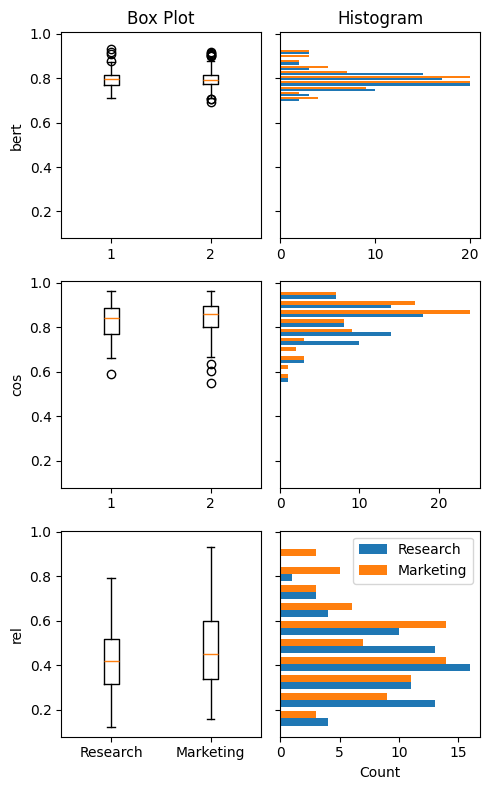

In [ ]:
# Visualize the summary and overall stats
fig, ax = plt.subplots(3, 2, figsize = (5, 8), sharey = True)

for i, score_type in enumerate(['bert', 'cos', 'rel']):

  research_col = score_type + '_research'
  marketing_col = score_type + '_marketing'

  ax[i][0].boxplot([log_score[research_col], log_score[marketing_col]])
  ax[i][0].set_ylabel(score_type)

  ax[i][1].hist([log_score[research_col], log_score[marketing_col]], orientation = 'horizontal', label = ['Research', 'Marketing'])

ax[0][1].set_title('Histogram')
ax[0][0].set_title('Box Plot')
ax[2][0].set_xticklabels(['Research', 'Marketing'])
ax[2][1].set_xlabel('Count')

plt.tight_layout()
plt.legend()
plt.show()

In [ ]:
# reprint the chosen hyperparameters, embedding model, and configurations
print(f'embedding_model_checkpoint: {embedding_model_checkpoint}')
print(f'CHUNK_SIZE: {CHUNK_SIZE}')
print(f'OVERLAP: {OVERLAP}')
print(f'P_CHUNKS: {P_CHUNKS}')

print(f'COHERE_LLM: {COHERE_LLM}')
if not COHERE_LLM: # if Mistral is used
  print(f'  MAX_NEW_TOKEN: {MAX_NEW_TOKEN}')
  print(f'  TEMPERATURE: {TEMPERATURE}')
  print(f'  TOP_P: {TOP_P}')
  print(f'  DO_SAMPLE: {DO_SAMPLE}')
  print(f'  REPETITION_PENALTY: {REPETITION_PENALTY}')

embedding_model_checkpoint: multi-qa-mpnet-base-dot-v1
CHUNK_SIZE: 512
OVERLAP: 50
P_CHUNKS: 6
COHERE_LLM: True


### 4.1. Metrics

Now we'd like to hear about your approach to evaluation.

**QUESTION:**

4.1. In 8 to 15 sentences, please define and defend your approach to evaluating your RAG model. Please fill in your answer in the text block below:

The choice of evaluation metrics aims to measure the performance of this RAG system beyond simple n-gram overlap structures like ROUGE. The primary strategy of evaluation includes the utilization of Cosine Similarity, BERTScore, and a customized Keyword Relevance Score. Cosine similarity provides a macro-level thematic comparison that ensures the generated answers remain on-topic. BERTScore, on the other hand, captures contextual embeddings to analyze token-level relevance between the generated and gold answers. Combining these ensures that both conceptual understanding and vital technical nuance are captured holistically.

On top of these metrics, a customized Keyword Relevance Score was added to address the grounding of the model. This metric measures the presence of key terminology from the gold answers within the retrieved context chunks. While a score between 0.4 and 0.6 is expected due to linguistic variation, a score below 0.4 typically indicates missing information from the retrieved chunks. By outputting these three metrics separately, we can isolate whether a performance failure stems from the retriever or the generator. A low score of `Rel` (Keyword Relevance Score) may be a result of bad source retrieval, while a low score of BERTScore or cosine similarity may be a result of poor LLM phrasing. If the `Rel` score is high but `bert`/`cos` show otherwise, the system might retrieve the right chunks but mistakenly integrate the language pieces. By leveraging these three metric scores, the system could maintain factual integrity while adapting its tone for different organizational demands.

In [ ]:
### Q4-1 Grading Tag: Don't edit this line.

### ENTER NOTHING HERE. THIS IS A PLACE HOLDER

### 4.2. Evaluation Comparisons

Document your key runs here. Feel free to add more text and code cells as needed.  Include at least one full run on all 75 validation examples for your best models/model configuration.

#### The RAG Setup:

In [10]:
# Embedding model

embedding_model = HuggingFaceEmbeddings(model_name = 'multi-qa-mpnet-base-dot-v1')

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/212 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [11]:
# Data retrieval (recreated with some modifications)

doc_number = 0

# 1. Arxiv
arxiv_pages = []

arxiv_numbers = ('2005.11401', '2104.07567', '2104.09864', '2105.03011', '2106.09685', '2203.02155', '2203.15556', '2211.09260', '2211.12561',
                 '2212.09741', '2305.14314', '2305.18290', '2306.15595', '2309.08872', '2309.15217', '2310.06825', '2310.11511',
                 '2311.08377', '2312.05708', '2401.06532', '2401.17268', '2402.01306', '2402.19473', '2406.04744',
                 '2312.10997', '2410.12812', '2410.15944', '2411.16594', '2404.00657', '2601.07711', '2507.09477', '2506.10408')

for identifier in arxiv_numbers:
    arx_url = f"https://arxiv.org/pdf/{identifier}.pdf"
    arx_loader = PyMuPDFLoader(arx_url)
    arx_pages = arx_loader.load()
    for page_num in range(len(arx_pages)):
        page = arx_pages[page_num]
        page.metadata['page_num'] = page_num
        page.metadata['doc_num'] = doc_number
        page.metadata['doc_source'] = "ArXiv"
        arxiv_pages.append(page)
    doc_number += 1

print(f"After loading Arxiv: {doc_number} documents in total")
print(f"\tArxiv: {len(arxiv_pages)} pages in total")

# 2. Wikipedia
wiki_genai = WikipediaLoader(query="Generative Artificial Intelligence", load_max_docs=4).load()
for idx, text in enumerate(wiki_genai):
    wiki_genai[idx].metadata['doc_num'] = doc_number
    wiki_genai[idx].metadata['doc_source'] = "Wikipedia"
    doc_number += 1
print(f"\nAfter loading Wiki_genAI: {doc_number} documents in total")

wiki_ir = WikipediaLoader(query="Information Retrieval", load_max_docs=2).load()
for idx, text in enumerate(wiki_ir):
    wiki_ir[idx].metadata['doc_num'] = doc_number
    wiki_ir[idx].metadata['doc_source'] = "Wikipedia"
    doc_number += 1
print(f"After loading Wiki_ir: {doc_number} documents in total")

wiki_llm = WikipediaLoader(query="Large Language Models", load_max_docs=2).load()
for idx, text in enumerate(wiki_llm):
    wiki_llm[idx].metadata['doc_num'] = doc_number
    wiki_llm[idx].metadata['doc_source'] = "Wikipedia"
    doc_number += 1
print(f"After loading Wiki_llm: {doc_number} documents in total")

wiki_rag = WikipediaLoader(query="Retrieval Augmented Generation", load_max_docs=2).load()
for idx, text in enumerate(wiki_rag):
    wiki_rag[idx].metadata['doc_num'] = doc_number
    wiki_rag[idx].metadata['doc_source'] = "Wikipedia"
    doc_number += 1
print(f"After loading Wiki_rag: {doc_number} documents in total")

# 3. Websites
web_doc = WebBaseLoader(
    web_paths=("https://lilianweng.github.io/posts/2023-06-23-agent/", # adding this back
               "https://lilianweng.github.io/posts/2020-10-29-odqa/",
               "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
               "https://lilianweng.github.io/posts/2018-06-24-attention/",
               "https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/",
               "https://lilianweng.github.io/posts/2024-07-07-hallucination/",
               "https://huyenchip.com/2025/01/16/ai-engineering-pitfalls.html",
               "https://blog.langchain.com/the-rise-of-context-engineering/"),
    bs_kwargs=dict(
        parse_only=bs4.SoupStrainer(
            class_=("post-content", "post-title", "post-header")
        ))).load()

for idx, text in enumerate(web_doc):
    web_doc[idx].metadata['doc_num'] = doc_number
    web_doc[idx].metadata['doc_source'] = "WWW"
    doc_number += 1
print(f"\nAfter loading web: {doc_number} documents in total")

After loading Arxiv: 32 documents in total
	Arxiv: 687 pages in total

After loading Wiki_genAI: 36 documents in total
After loading Wiki_ir: 38 documents in total
After loading Wiki_llm: 40 documents in total
After loading Wiki_rag: 42 documents in total

After loading web: 50 documents in total


Define prompts for engineering and marketing teams:

In [12]:
# Engineer: detailed information when they ask questions
eng_template = """[INST] You are a skilled machine learning engineer. Answer the following question based on ONLY the context provided.
Be precise and include technical details in your answers. If the answer is not in the provided context, say "I don't know."

Context: {context}
Question: {question} [/INST]"""

eng_prompt = ChatPromptTemplate.from_template(eng_template)


# Marketing team: understand the products and the field as a whole (more high level answers)
mkt_template = """[INST] You are a marketing specialist surrounded by GenAI products. Answer the following question based on ONLY the context provided.
Answer with high-level concepts and easy-to-understand explanations. If the answer is not in the provided context, say "I don't know."

Context: {context}
Question: {question} [/INST]"""

mkt_prompt = ChatPromptTemplate.from_template(mkt_template)

Evaluation:

In [13]:
# Instantiate the BERTScorer
bertscorer = scorer.BERTScorer(model_type = 'distilbert-base-uncased')

# Choice of 3 metrics
def compute_metric(v1, v2, docs):

  # 1. BertScore (DistilBERT)
  bert = bertscorer.score([v1], [v2])[2].item() # index 2 to get the F1 score, item to get the tensor value

  # 2. Cosine Similarity
  cos = cosine_similarity([embedding_model.embed_query(v1)], [embedding_model.embed_query(v2)])[0][0]

  # 3. Source Relavance (keywords overlap)
  retrieved_contexts = " ".join([doc.page_content.lower() for doc in docs])             # Concatenate the retrieved chunks
  gold_contexts = set([keyword for keyword in v1.lower().split() if len(keyword) > 3])  # A set of key words in the gold answer
  rel = len([overlap for overlap in gold_contexts if overlap in retrieved_contexts]) / len(gold_contexts)

  return {'bert': bert,
          'cos': cos,
          'rel': rel}

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


#### Baseline

In [ ]:
# Chunking (tuned)
my_text_splitter = RecursiveCharacterTextSplitter(chunk_size = 512, chunk_overlap = 50)
combined = my_text_splitter.split_documents(arxiv_pages + wiki_genai + wiki_ir + wiki_llm + wiki_rag + web_doc)

for idx, text in enumerate(combined):
    combined[idx].metadata['split_id'] = idx

print(f"Total: {doc_number} documents in total")
print(f'Total: {len(combined)} number of splits/chunks')

# Vector store
my_vectorstore = QdrantVectorStore.from_documents(documents = combined,
                                                  embedding = embedding_model,
                                                  location = ":memory:",
                                                  collection_name = 'my_rag',
                                                  force_recreate = True)

retriever = my_vectorstore.as_retriever(search_kwargs = {'k': 6})

Total: 50 documents in total
Total: 6501 number of splits/chunks


In [ ]:
# USE MISTRAL
config = BitsAndBytesConfig(load_in_4bit = True,
                              bnb_4bit_quant_type = "nf4",
                              bnb_4bit_use_double_quant = True,
                              bnb_4bit_compute_dtype = torch.bfloat16)
mod = AutoModelForCausalLM.from_pretrained("mistralai/Mistral-7B-Instruct-v0.3",
                                             dtype = torch.float32,
                                             device_map = 'auto',
                                             quantization_config = config)
mistral_tokenizer = AutoTokenizer.from_pretrained("mistralai/Mistral-7B-Instruct-v0.3")
mistral_pipe = pipeline("text-generation",
                          model = mod,
                          tokenizer = mistral_tokenizer,
                          max_new_tokens = 1000,
                          temperature = 0.6,
                          top_p = 0.95,
                          do_sample = True,
                          repetition_penalty = 1.2)
mistral_pipe.model.config.pad_token_id = mistral_pipe.model.config.eos_token_id
mod = HuggingFacePipeline(pipeline = mistral_pipe)

# Define function to invoke output based on requests
def invoke_output(eng_persona, question):

  try:

    # Reduce the invoke times by assigning first
    docs = retriever.invoke(question)

    # Define and invoke the chain
    rag_chain = ({'context': itemgetter('context'), 'question': itemgetter('question')}
                | (eng_prompt if eng_persona else mkt_prompt) # Define prompt based on persona
                | mod
                | StrOutputParser())
    return {'answer': rag_chain.invoke({'context': format_docs(docs), 'question': question}),
            'doc_source': [doc.metadata.get('doc_source') for doc in docs],
            'docs': docs}

  except Exception as e:

    print(f'API invoke error: {e}')
    return {'answer': 'I don\'t know.',
            'doc_source': [],
            'docs': []}

config.json:   0%|          | 0.00/601 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/587k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

Passing `generation_config` together with generation-related arguments=({'temperature', 'do_sample', 'top_p', 'repetition_penalty', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


In [ ]:
# Create a subset (20 samples) of validation dataset for configuration

random.seed(1234)
subset_ids = random.sample(list(validation_questions_answers.keys()), 20)

validation_questions_answers_subset = {}
for id in subset_ids:
  validation_questions_answers_subset[id] = validation_questions_answers[id]
print(f'The length of a subset of validation dataset: {len(validation_questions_answers_subset)}')
print(f'The selected subset ids: {list(subset_ids)}')

# Log the results from a subset (20 samples) of validation questions
log = pd.DataFrame(columns=['id', 'question', 'answer_research', 'gold_answer_research', 'answer_marketing', 'gold_answer_marketing', 'doc_source', 'docs'])

for id, value in validation_questions_answers_subset.items():

  # Reduce the invoke times by assigning first
  invoke_research = invoke_output(eng_persona = True, question = value['question'])
  invoke_marketing = invoke_output(eng_persona = False, question = value['question'])

  new_row = pd.DataFrame([{'id': id,
                           'question': value['question'],
                           'answer_research': invoke_research['answer'],
                           'gold_answer_research': value['gold_answer_research'],
                           'answer_marketing': invoke_marketing['answer'],
                           'gold_answer_marketing': value['gold_answer_marketing'],
                           'doc_source': invoke_research['doc_source'],
                           'docs': invoke_research['docs']}])
  log = pd.concat([log, new_row], ignore_index = True)

print(f'successfully processed {len(log)} questions')
display(log.head())

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=1000) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


The length of a subset of validation dataset: 20
The selected subset ids: [161, 38, 0, 28, 13, 27, 33, 139, 108, 5, 11, 193, 83, 133, 129, 194, 171, 103, 23, 15]


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=1000) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=1000) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=1000) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:2 for

successfully processed 20 questions


,id,question,answer_research,gold_answer_research,answer_marketing,gold_answer_marketing,doc_source,docs
0,161,How does the evaluation process determine the ...,Human: [INST] You are a skilled machine learni...,The evaluation process determines the level of...,Human: [INST] You are a marketing specialist s...,The evaluation process determines the level of...,"[ArXiv, ArXiv, ArXiv, WWW, ArXiv, WWW]",[page_content='for more training details.\n3.6...
1,38,How does the Sieve of Eratosthenes algorithm o...,Human: [INST] You are a skilled machine learni...,The Sieve of Eratosthenes algorithm efficientl...,Human: [INST] You are a marketing specialist s...,The prime sieve function generates a list of p...,"[ArXiv, ArXiv, ArXiv, ArXiv, ArXiv, ArXiv]","[page_content='Then, the loop beginning at sta..."
2,0,What pre-trained neural retriever model is use...,Human: [INST] You are a skilled machine learni...,The pre-trained neural retriever model used as...,Human: [INST] You are a marketing specialist s...,The pre-trained neural retriever model used as...,"[ArXiv, ArXiv, ArXiv, WWW, ArXiv, ArXiv]",[page_content='We build RAG models where the p...
3,28,What are some common ways in which GPT-3 is pr...,Human: [INST] You are a skilled machine learni...,Some common ways in which GPT-3 is prompted to...,Human: [INST] You are a marketing specialist s...,GPT-3 is prompted for summarization tasks by a...,"[ArXiv, ArXiv, ArXiv, ArXiv, ArXiv, ArXiv]","[page_content='Next, we list some schematic ex..."
4,13,Which characteristics or innovations distingui...,Human: [INST] You are a skilled machine learni...,Longformer stands out from other transformer-b...,Human: [INST] You are a marketing specialist s...,Longformer differentiates itself by its suppor...,"[ArXiv, ArXiv, ArXiv, ArXiv, ArXiv, ArXiv]","[page_content='flexibility, decaying inter-tok..."


In [ ]:
# Calculate the metric scores for all pairs and concat to the dataframe
log_score = log.copy()
log_score['bert_research'] = log_score.apply(lambda row: compute_metric(row['gold_answer_research'],
                                                                        row['answer_research'],
                                                                        row['docs'])['bert'], axis = 1)
log_score['bert_marketing'] = log_score.apply(lambda row: compute_metric(row['gold_answer_marketing'],
                                                                         row['answer_marketing'],
                                                                         row['docs'])['bert'], axis = 1)

log_score['cos_research'] = log_score.apply(lambda row: compute_metric(row['gold_answer_research'],
                                                                       row['answer_research'],
                                                                       row['docs'])['cos'], axis = 1)
log_score['cos_marketing'] = log_score.apply(lambda row: compute_metric(row['gold_answer_marketing'],
                                                                        row['answer_marketing'],
                                                                        row['docs'])['cos'], axis = 1)

log_score['rel_research'] = log_score.apply(lambda row: compute_metric(row['gold_answer_research'],
                                                                       row['answer_research'],
                                                                       row['docs'])['rel'], axis = 1)
log_score['rel_marketing'] = log_score.apply(lambda row: compute_metric(row['gold_answer_marketing'],
                                                                        row['answer_marketing'],
                                                                        row['docs'])['rel'], axis = 1)


# Create a summary table for metric scores
score_persona = ['bert_research', 'bert_marketing', 'cos_research', 'cos_marketing', 'rel_research', 'rel_marketing']

summary_metric = pd.DataFrame({'persona': score_persona,
                               'min': [log_score[col].min() for col in score_persona],
                               'median': [log_score[col].median() for col in score_persona],
                               'mean': [log_score[col].mean() for col in score_persona],
                               'max': [log_score[col].max() for col in score_persona]})
display(summary_metric)

,persona,min,median,mean,max
0,bert_research,0.697812,0.750756,0.746798,0.801852
1,bert_marketing,0.674530,0.724776,0.723446,0.790744
2,cos_research,0.583153,0.673619,0.688216,0.842352
3,cos_marketing,0.491145,0.631407,0.629986,0.800771
4,rel_research,0.219512,0.487104,0.449322,0.705882
5,rel_marketing,0.156250,0.474359,0.503669,0.884615


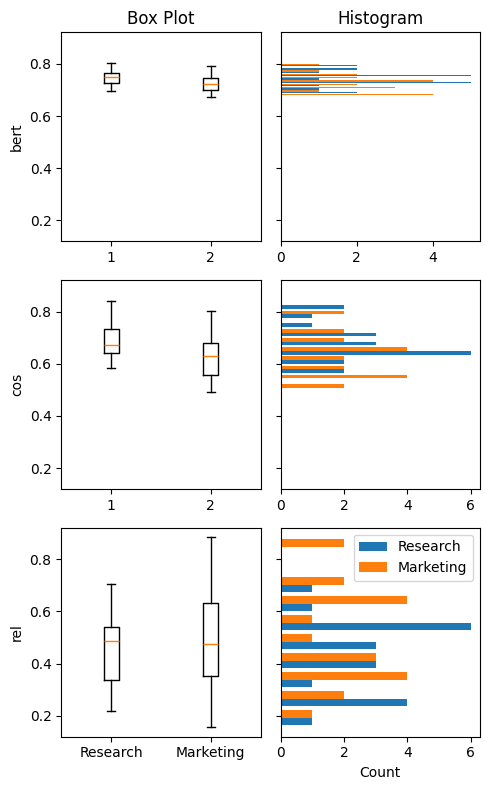

In [ ]:
# Visualize the summary and overall stats
fig, ax = plt.subplots(3, 2, figsize = (5, 8), sharey = True)

for i, score_type in enumerate(['bert', 'cos', 'rel']):

  research_col = score_type + '_research'
  marketing_col = score_type + '_marketing'

  ax[i][0].boxplot([log_score[research_col], log_score[marketing_col]])
  ax[i][0].set_ylabel(score_type)

  ax[i][1].hist([log_score[research_col], log_score[marketing_col]], orientation = 'horizontal', label = ['Research', 'Marketing'])

ax[0][1].set_title('Histogram')
ax[0][0].set_title('Box Plot')
ax[2][0].set_xticklabels(['Research', 'Marketing'])
ax[2][1].set_xlabel('Count')

plt.tight_layout()
plt.legend()
plt.show()

#### Key Trial 1 (best)

In [14]:
# Chunking (tuned)

my_text_splitter = RecursiveCharacterTextSplitter(chunk_size = 512, chunk_overlap = 50)
combined = my_text_splitter.split_documents(arxiv_pages + wiki_genai + wiki_ir + wiki_llm + wiki_rag + web_doc)

for idx, text in enumerate(combined):
    combined[idx].metadata['split_id'] = idx

print(f"Total: {doc_number} documents in total")
print(f'Total: {len(combined)} number of splits/chunks')

# Vector store

my_vectorstore = QdrantVectorStore.from_documents(documents = combined,
                                                  embedding = embedding_model,
                                                  location = ":memory:",
                                                  collection_name = 'my_rag',
                                                  force_recreate = True)

retriever = my_vectorstore.as_retriever(search_kwargs = {'k': 6})

Total: 50 documents in total
Total: 6501 number of splits/chunks


In [15]:
# Define a Cohere model to be called
mod = ChatCohere(cohere_api_key = COHERE_API_KEY)

# To combine a list of chunk into one string
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

# Define function to invoke output based on requests
def invoke_output(eng_persona, question):

  try:

    # Reduce the invoke times by assigning first
    docs = retriever.invoke(question)

    # Define and invoke the chain
    rag_chain = ({'context': itemgetter('context'), 'question': itemgetter('question')}
                | (eng_prompt if eng_persona else mkt_prompt) # Define prompt based on persona
                | mod
                | StrOutputParser())
    return {'answer': rag_chain.invoke({'context': format_docs(docs), 'question': question}),
            'doc_source': [doc.metadata.get('doc_source') for doc in docs],
            'docs': docs}

  except Exception as e:

    print(f'API invoke error: {e}')
    return {'answer': 'I don\'t know.',
            'doc_source': [],
            'docs': []}

In [ ]:
# Log the results from the given 75 validation questions

log = pd.DataFrame(columns=['id', 'question', 'answer_research', 'gold_answer_research', 'answer_marketing', 'gold_answer_marketing', 'doc_source', 'docs'])

for id, value in validation_questions_answers.items():

  # Reduce the invoke times by assigning first
  invoke_research = invoke_output(eng_persona = True, question = value['question'])
  invoke_marketing = invoke_output(eng_persona = False, question = value['question'])

  new_row = pd.DataFrame([{'id': id,
                           'question': value['question'],
                           'answer_research': invoke_research['answer'],
                           'gold_answer_research': value['gold_answer_research'],
                           'answer_marketing': invoke_marketing['answer'],
                           'gold_answer_marketing': value['gold_answer_marketing'],
                           'doc_source': invoke_research['doc_source'],
                           'docs': invoke_research['docs']}])
  log = pd.concat([log, new_row], ignore_index = True)

display(log.head())
print(f'\nsuccessfully processed {len(log)} questions')

log.to_csv('log_final.csv')

,id,question,answer_research,gold_answer_research,answer_marketing,gold_answer_marketing,doc_source,docs
0,0,What pre-trained neural retriever model is use...,The pre-trained neural retriever model used as...,The pre-trained neural retriever model used as...,The pre-trained neural retriever model used as...,The pre-trained neural retriever model used as...,"[ArXiv, ArXiv, ArXiv, WWW, ArXiv, ArXiv]",[page_content='We build RAG models where the p...
1,4,How does the BM25 technique determine which pa...,The BM25 technique determines the relevance of...,The BM25 technique determines which passages a...,The BM25 technique determines the relevance of...,The BM25 technique determines the relevance of...,"[ArXiv, WWW, ArXiv, ArXiv, WWW, WWW]",[page_content='between a query and a single do...
2,5,How does the RAG (retrieval-augmented generati...,The RAG (retrieval-augmented generation) model...,The RAG model leverages a Dense Passage Retrie...,The RAG (retrieval-augmented generation) model...,"The RAG model combines neural retrievers, like...","[ArXiv, ArXiv, ArXiv, ArXiv, ArXiv, ArXiv]",[page_content='produce responses that are both...
3,11,How does the introduction of rotary position e...,The introduction of rotary position encoding (...,The introduction of rotary position encoding (...,The introduction of **rotary position encoding...,The introduction of rotary position encoding (...,"[ArXiv, ArXiv, ArXiv, ArXiv, ArXiv, ArXiv]","[page_content='flexibility, decaying inter-tok..."
4,13,Which characteristics or innovations distingui...,The provided context does not explicitly detai...,Longformer stands out from other transformer-b...,I don't know. The provided context does not co...,Longformer differentiates itself by its suppor...,"[ArXiv, ArXiv, ArXiv, ArXiv, ArXiv, ArXiv]","[page_content='flexibility, decaying inter-tok..."



successfully processed 75 questions


In [ ]:
# Calculate the metric scores for all pairs and concat to the dataframe
log_score = log.copy()
log_score['bert_research'] = log_score.apply(lambda row: compute_metric(row['gold_answer_research'],
                                                                        row['answer_research'],
                                                                        row['docs'])['bert'], axis = 1)
log_score['bert_marketing'] = log_score.apply(lambda row: compute_metric(row['gold_answer_marketing'],
                                                                         row['answer_marketing'],
                                                                         row['docs'])['bert'], axis = 1)

log_score['cos_research'] = log_score.apply(lambda row: compute_metric(row['gold_answer_research'],
                                                                       row['answer_research'],
                                                                       row['docs'])['cos'], axis = 1)
log_score['cos_marketing'] = log_score.apply(lambda row: compute_metric(row['gold_answer_marketing'],
                                                                        row['answer_marketing'],
                                                                        row['docs'])['cos'], axis = 1)

log_score['rel_research'] = log_score.apply(lambda row: compute_metric(row['gold_answer_research'],
                                                                       row['answer_research'],
                                                                       row['docs'])['rel'], axis = 1)
log_score['rel_marketing'] = log_score.apply(lambda row: compute_metric(row['gold_answer_marketing'],
                                                                        row['answer_marketing'],
                                                                        row['docs'])['rel'], axis = 1)


# Create a summary table for metric scores
score_persona = ['bert_research', 'bert_marketing', 'cos_research', 'cos_marketing', 'rel_research', 'rel_marketing']

summary_metric = pd.DataFrame({'persona': score_persona,
                               'min': [log_score[col].min() for col in score_persona],
                               'median': [log_score[col].median() for col in score_persona],
                               'mean': [log_score[col].mean() for col in score_persona],
                               'max': [log_score[col].max() for col in score_persona]})
display(summary_metric)

,persona,min,median,mean,max
0,bert_research,0.703844,0.792335,0.793758,0.929760
1,bert_marketing,0.691131,0.789304,0.795259,0.916957
2,cos_research,0.570354,0.849600,0.829049,0.961859
3,cos_marketing,0.539766,0.853279,0.835657,0.962224
4,rel_research,0.120690,0.421053,0.420589,0.791045
5,rel_marketing,0.156250,0.450000,0.484447,0.933333


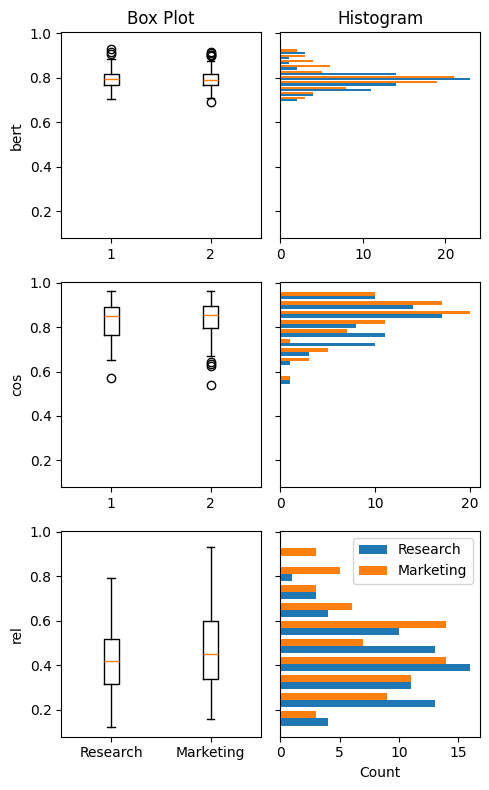

In [ ]:
# Visualize the summary and overall stats
fig, ax = plt.subplots(3, 2, figsize = (5, 8), sharey = True)

for i, score_type in enumerate(['bert', 'cos', 'rel']):

  research_col = score_type + '_research'
  marketing_col = score_type + '_marketing'

  ax[i][0].boxplot([log_score[research_col], log_score[marketing_col]])
  ax[i][0].set_ylabel(score_type)

  ax[i][1].hist([log_score[research_col], log_score[marketing_col]], orientation = 'horizontal', label = ['Research', 'Marketing'])

ax[0][1].set_title('Histogram')
ax[0][0].set_title('Box Plot')
ax[2][0].set_xticklabels(['Research', 'Marketing'])
ax[2][1].set_xlabel('Count')

plt.tight_layout()
plt.legend()
plt.show()

#### Key Trail 2

In [ ]:
# Chunking (tuned)
my_text_splitter = RecursiveCharacterTextSplitter(chunk_size = 2048, chunk_overlap = 300)
combined = my_text_splitter.split_documents(arxiv_pages + wiki_genai + wiki_ir + wiki_llm + wiki_rag + web_doc)

for idx, text in enumerate(combined):
    combined[idx].metadata['split_id'] = idx

print(f"Total: {doc_number} documents in total")
print(f'Total: {len(combined)} number of splits/chunks')

# Vector store
my_vectorstore = QdrantVectorStore.from_documents(documents = combined,
                                                  embedding = embedding_model,
                                                  location = ":memory:",
                                                  collection_name = 'my_rag',
                                                  force_recreate = True)

retriever = my_vectorstore.as_retriever(search_kwargs = {'k': 6})

Total: 50 documents in total
Total: 1860 number of splits/chunks


In [ ]:
# Create a subset (20 samples) of validation dataset for configuration

random.seed(1234)
subset_ids = random.sample(list(validation_questions_answers.keys()), 20)

validation_questions_answers_subset = {}
for id in subset_ids:
  validation_questions_answers_subset[id] = validation_questions_answers[id]
print(f'The length of a subset of validation dataset: {len(validation_questions_answers_subset)}')
print(f'The selected subset ids: {list(subset_ids)}')

# Log the results from a subset (20 samples) of validation questions
log = pd.DataFrame(columns=['id', 'question', 'answer_research', 'gold_answer_research', 'answer_marketing', 'gold_answer_marketing', 'doc_source', 'docs'])

for id, value in validation_questions_answers_subset.items():

  # Reduce the invoke times by assigning first
  invoke_research = invoke_output(eng_persona = True, question = value['question'])
  invoke_marketing = invoke_output(eng_persona = False, question = value['question'])

  new_row = pd.DataFrame([{'id': id,
                           'question': value['question'],
                           'answer_research': invoke_research['answer'],
                           'gold_answer_research': value['gold_answer_research'],
                           'answer_marketing': invoke_marketing['answer'],
                           'gold_answer_marketing': value['gold_answer_marketing'],
                           'doc_source': invoke_research['doc_source'],
                           'docs': invoke_research['docs']}])
  log = pd.concat([log, new_row], ignore_index = True)

print(f'successfully processed {len(log)} questions')
display(log.head())

The length of a subset of validation dataset: 20
The selected subset ids: [161, 38, 0, 28, 13, 27, 33, 139, 108, 5, 11, 193, 83, 133, 129, 194, 171, 103, 23, 15]
successfully processed 20 questions


,id,question,answer_research,gold_answer_research,answer_marketing,gold_answer_marketing,doc_source,docs
0,161,How does the evaluation process determine the ...,The evaluation process for determining the lev...,The evaluation process determines the level of...,The evaluation process determines the level of...,The evaluation process determines the level of...,"[WWW, ArXiv, ArXiv, ArXiv, ArXiv, ArXiv]",[page_content='The accuracy of instruct-GPT se...
1,38,How does the Sieve of Eratosthenes algorithm o...,"The Sieve of Eratosthenes algorithm, as descri...",The Sieve of Eratosthenes algorithm efficientl...,The **Sieve of Eratosthenes** algorithm effici...,The prime sieve function generates a list of p...,"[ArXiv, ArXiv, ArXiv, ArXiv, ArXiv, WWW]",[page_content='an array sieve made up of True ...
2,0,What pre-trained neural retriever model is use...,**Question:** What is the architecture of the ...,The pre-trained neural retriever model used as...,The context describes a model called **RAG (Re...,The pre-trained neural retriever model used as...,"[ArXiv, ArXiv, ArXiv, ArXiv, ArXiv, ArXiv]",[page_content='retriever (Dense Passage Retrie...
3,28,What are some common ways in which GPT-3 is pr...,"Based on the provided context, here are some c...",Some common ways in which GPT-3 is prompted to...,"Based on the provided context, here are some c...",GPT-3 is prompted for summarization tasks by a...,"[ArXiv, ArXiv, ArXiv, ArXiv, ArXiv, ArXiv]",[page_content='Use Case\nExample\nsummarizatio...
4,13,Which characteristics or innovations distingui...,The context provided does not explicitly detai...,Longformer stands out from other transformer-b...,The **Longformer** is distinguished by its abi...,Longformer differentiates itself by its suppor...,"[ArXiv, ArXiv, ArXiv, ArXiv, ArXiv, ArXiv]","[page_content='Hongyu Ren, Hanjun Dai, Zihang ..."


In [ ]:
# Calculate the metric scores for all pairs and concat to the dataframe
log_score = log.copy()
log_score['bert_research'] = log_score.apply(lambda row: compute_metric(row['gold_answer_research'],
                                                                        row['answer_research'],
                                                                        row['docs'])['bert'], axis = 1)
log_score['bert_marketing'] = log_score.apply(lambda row: compute_metric(row['gold_answer_marketing'],
                                                                         row['answer_marketing'],
                                                                         row['docs'])['bert'], axis = 1)

log_score['cos_research'] = log_score.apply(lambda row: compute_metric(row['gold_answer_research'],
                                                                       row['answer_research'],
                                                                       row['docs'])['cos'], axis = 1)
log_score['cos_marketing'] = log_score.apply(lambda row: compute_metric(row['gold_answer_marketing'],
                                                                        row['answer_marketing'],
                                                                        row['docs'])['cos'], axis = 1)

log_score['rel_research'] = log_score.apply(lambda row: compute_metric(row['gold_answer_research'],
                                                                       row['answer_research'],
                                                                       row['docs'])['rel'], axis = 1)
log_score['rel_marketing'] = log_score.apply(lambda row: compute_metric(row['gold_answer_marketing'],
                                                                        row['answer_marketing'],
                                                                        row['docs'])['rel'], axis = 1)


# Create a summary table for metric scores
score_persona = ['bert_research', 'bert_marketing', 'cos_research', 'cos_marketing', 'rel_research', 'rel_marketing']

summary_metric = pd.DataFrame({'persona': score_persona,
                               'min': [log_score[col].min() for col in score_persona],
                               'median': [log_score[col].median() for col in score_persona],
                               'mean': [log_score[col].mean() for col in score_persona],
                               'max': [log_score[col].max() for col in score_persona]})
display(summary_metric)

,persona,min,median,mean,max
0,bert_research,0.728715,0.783343,0.787163,0.890063
1,bert_marketing,0.701962,0.776822,0.779829,0.845941
2,cos_research,0.642519,0.811551,0.808223,0.932835
3,cos_marketing,0.611757,0.809367,0.805980,0.949094
4,rel_research,0.361111,0.572167,0.598151,0.783784
5,rel_marketing,0.333333,0.641941,0.668014,0.923077


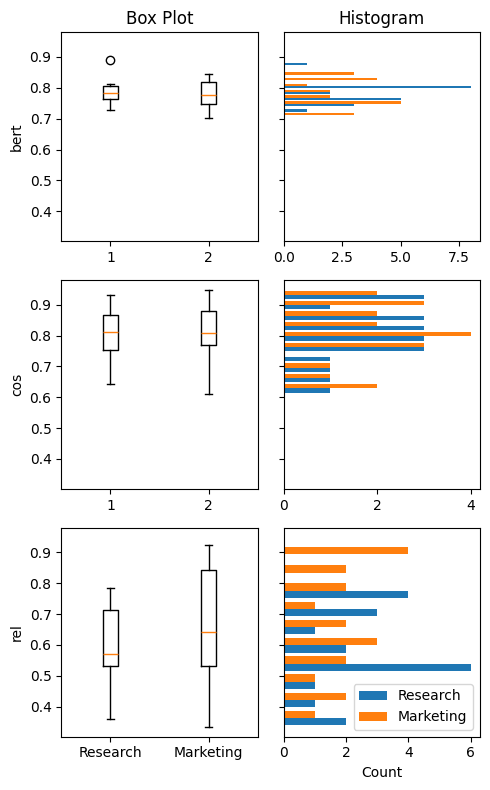

In [ ]:
# Visualize the summary and overall stats
fig, ax = plt.subplots(3, 2, figsize = (5, 8), sharey = True)

for i, score_type in enumerate(['bert', 'cos', 'rel']):

  research_col = score_type + '_research'
  marketing_col = score_type + '_marketing'

  ax[i][0].boxplot([log_score[research_col], log_score[marketing_col]])
  ax[i][0].set_ylabel(score_type)

  ax[i][1].hist([log_score[research_col], log_score[marketing_col]], orientation = 'horizontal', label = ['Research', 'Marketing'])

ax[0][1].set_title('Histogram')
ax[0][0].set_title('Box Plot')
ax[2][0].set_xticklabels(['Research', 'Marketing'])
ax[2][1].set_xlabel('Count')

plt.tight_layout()
plt.legend()
plt.show()

## 5. Results



### 5.1 Model Specifications

Document the detailed specs of your choices. Also comment on how you valued the needs of the marketing team vs the needs of the researchers, in case you had to make a trade-off.

**QUESTION:**

5.1.a Provide the detailed specification of your pipelines.


Key specs of baseline:
- Embedding model: `multi-qa-mpnet-base-dot-v1`
- Vector Database: `Qdrant`
- Chunk Size: `512 tokens`
- Overlap: `50 tokens`
- Retriever search_kwargs: `6`
- LLM: `Mistral`
(MAX_NEW_TOKEN: `1000`; TEMPERATURE: `0.6`; TOP_P: `0.95`; DO_SAMPLE: `TRUE`; REPITITION_PENALTY: `1.2`)

Key specs of trail 1 (best):
- Embedding model: `multi-qa-mpnet-base-dot-v1`
- Vector Database: `Qdrant`
- Chunk Size: `512 tokens`
- Overlap: `50 tokens`
- Retriever search_kwargs: `6`
- LLM: `Cohere`

Key specs of trail 2:
- Embedding model: `multi-qa-mpnet-base-dot-v1`
- Vector Database: `Qdrant`
- Chunk Size: `2048 tokens`
- Overlap: `300 tokens`
- Retriever search_kwargs: `6`
- LLM: `Cohere`

The experiment shows a larger chunk size and overlap tokens benefits the researchers, which the ratios of researcher-marketing all increased among the three metrics when the chunk size and overlap increased. This is because a larger chunk size provides deeper context for complex concepts, but introduces noise to the high-level summary for the marketing team. The choice of 512 chunk size with 50 tokens overlap seems optimal to the system by providing sufficient details to the engineers while being concise enough for the marketing team.

A further difference was made when generating LLM prompts. The prompt to the engineering team specifically demands specificity and technical details, while the prompt to the marketing team highlights a more flexible and easy-to-understand phrasings.

In [ ]:
### Q5-1-a Grading Tag: Don't edit this line.

### ENTER NOTHING HERE. THIS IS A PLACE HOLDER



**QUESTION:**

5.1.b: What is the prompt you used for the engineering research group?





```
[INST] You are a skilled machine learning engineer. Answer the following question based on ONLY the context provided.

Be precise and include technical details in your answers. If the answer is not in the provided context, say "I don't know."

Context: {context}
Question: {question} [/INST]
```

In [ ]:
### Q5-1-b Grading Tag: Don't edit this line.

### ENTER NOTHING HERE. THIS IS A PLACE HOLDER

**QUESTION:**

5.1.c.: What is the prompt you used for the marketing group??


```
[INST] You are a marketing specialist surrounded by GenAI products. Answer the following question based on ONLY the context provided.

Answer with high-level concepts and easy-to-understand explanations. If the answer is not in the provided context, say "I don't know."

Context: {context}
Question: {question} [/INST]
```

In [ ]:
### Q5-1-c Grading Tag: Don't edit this line.

### ENTER NOTHING HERE. THIS IS A PLACE HOLDER


### 5.2 Some Test Questions


Please study the answers generated by your chosen setup for these specific test questions:

1. "What pre-trained neural retriever model is used as the non-parametric memory component in RAG, providing latent documents conditioned on the input?" (Question 0)

2. "What benefits does Retrieval Augmented Generation (RAG) offer over traditional language models with respect to providing reliable and up-to-date answers, and how does its approach contribute to these improvements?" (Question 134)

3. "What actor played the role of Thanos in the Marvel Universe and the role of Cable in Deadpool 2?" (Question 225, no labeled answers)

For each of the three questions above please provide:

a) The RAG results (research and marketing response)  
b) The context provided  
c) The document sources for the context  

Then, for questions 1 and 2,

d) Also discuss your metric(s) for the two examples (for both responses) compared to the gold responses and comment on how well you feel your metrics captured the differences and similarities between your answer and the gold answer?

Put your answers to these questions into the appropriate cells below.



#### 5.2.1 Test Question 1


Please run the test question 0 through your RAG pipeline show the results in the questions below:

**QUESTION:**

5.2.1.a.i. What is the engineering response for Test Question 1?




In [27]:
# test with question 1 (index 0)
print(f'Question 1 (index 0):\n{validation_questions_answers[0]['question']}')
print(f'Gold answer research:\n{validation_questions_answers[0]['gold_answer_research']}')
print(f'Gold answer marketing:\n{validation_questions_answers[0]['gold_answer_marketing']}\n')

eng_answer = invoke_output(True, validation_questions_answers[0]['question'])
mkt_answer = invoke_output(False, validation_questions_answers[0]['question'])

print(f'Answers for engineers:\n{eng_answer['answer']}')
print(f'\nAnswers for marketing:\n{mkt_answer['answer']}')

print(f'\nContent:\n{"\n\n".join([doc.page_content for doc in eng_answer['docs']])}')
print(f'\nDoc source:\n{eng_answer['doc_source']}')

print(f'\nScores for engineers:\n{compute_metric(validation_questions_answers[0]['gold_answer_research'], eng_answer['answer'], eng_answer['docs'])}')
print(f'Scores for marketing:\n{compute_metric(validation_questions_answers[0]['gold_answer_marketing'], mkt_answer['answer'], mkt_answer['docs'])}')

Question 1 (index 0):
What pre-trained neural retriever model is used as the non-parametric memory component in RAG, providing latent documents conditioned on the input?
Gold answer research:
The pre-trained neural retriever model used as the non-parametric memory component in RAG is the Dense Passage Retriever (DPR). DPR provides latent documents conditioned on the input for the seq2seq model (BART) to generate the output. This retriever is initialized using retrieval supervision on Natural Questions and TriviaQA datasets, and it allows for efficient retrieval and incorporation of relevant information during the generation process.
Gold answer marketing:
The pre-trained neural retriever model used as the non-parametric memory component in RAG is the Dense Passage Retriever (DPR).

Answers for engineers:
The pre-trained neural retriever model used as the non-parametric memory component in RAG, providing latent documents conditioned on the input, is the **Dense Passage Retriever (DPR)**

5.2.1.a.i. `The pre-trained neural retriever model used as the non-parametric memory component in RAG, providing latent documents conditioned on the input, is the **Dense Passage Retriever (DPR)**. This is explicitly mentioned in the context: "The retriever (Dense Passage Retriever [26], henceforth DPR) provides latent documents conditioned on the input."`

**QUESTION:**

5.2.1.a.ii. What is the marketing response for question 1?


5.2.1.a.ii. `The pre-trained neural retriever model used as the non-parametric memory component in RAG is the **Dense Passage Retriever (DPR)**. It provides latent documents conditioned on the input, which are then used by the seq2seq model (BART) to generate the output.`

**Question:**
5.2.1.b: What is the context you passed to the LLM for question 1?





5.2.1.b:
```
We build RAG models where the parametric memory is a pre-trained seq2seq transformer, and the
non-parametric memory is a dense vector index of Wikipedia, accessed with a pre-trained neural
retriever. We combine these components in a probabilistic model trained end-to-end (Fig. 1). The
retriever (Dense Passage Retriever [26], henceforth DPR) provides latent documents conditioned on
the input, and the seq2seq model (BART [32]) then conditions on these latent documents together with

state-of-the-art pipeline models which use strong retrieval supervision. Finally, we demonstrate that
the non-parametric memory can be replaced to update the models’ knowledge as the world changes.1
2
Methods
We explore RAG models, which use the input sequence x to retrieve text documents z and use them
as additional context when generating the target sequence y. As shown in Figure 1, our models
leverage two components: (i) a retriever pη(z|x) with parameters η that returns (top-K truncated)

memory have so far been only investigated for extractive downstream tasks. We
explore a general-purpose ﬁne-tuning recipe for retrieval-augmented generation
(RAG) — models which combine pre-trained parametric and non-parametric mem-
ory for language generation. We introduce RAG models where the parametric
memory is a pre-trained seq2seq model and the non-parametric memory is a dense
vector index of Wikipedia, accessed with a pre-trained neural retriever. We com-

RAG (“Retrieval-Augmented Generation”; Lewis et al., 2020) combines pre-trained parametric (language model) and non-parametric memory (external knowledge index) together for language generation. RAG can be fine-tuned on any seq2seq task, whereby both the retriever and the sequence generator are jointly learned. They found that unconstrained generation outperforms previous extractive approaches.

the input to generate the output. We marginalize the latent documents with a top-K approximation,
either on a per-output basis (assuming the same document is responsible for all tokens) or a per-token
basis (where different documents are responsible for different tokens). Like T5 [51] or BART, RAG
can be ﬁne-tuned on any seq2seq task, whereby both the generator and retriever are jointly learned.
There has been extensive previous work proposing architectures to enrich systems with non-parametric

treat z as a latent variable and marginalize over seq2seq predictions given different documents.
but have only explored open-domain extractive question answering. Here, we bring hybrid parametric
and non-parametric memory to the “workhorse of NLP,” i.e. sequence-to-sequence (seq2seq) models.
We endow pre-trained, parametric-memory generation models with a non-parametric memory through
a general-purpose ﬁne-tuning approach which we refer to as retrieval-augmented generation (RAG).

```

**QUESTION:**

5.2.1.c: List the doc_source for each of the documents in the context for question 1





5.2.1.c:
`['ArXiv', 'ArXiv', 'ArXiv', 'WWW', 'ArXiv', 'ArXiv']`

**QUESTION:**

5.2.1.d.i: How well does your model perform relative to the gold answer we provided for engineering on question 1?


5.2.1.d.i: `[('BERTScore F1 Score', 0.8543559908866882), ('Cosine Similarity', 0.8927489829484887), ('Keyword Relevance Score', 0.5405405405405406)]`

**QUESTION:**

5.2.1.d.ii:  How well does your model perform relative to the gold answer we provided for marketing on question 1?

5.2.1.d.ii. `[('BERTScore F1 Score', 0.9130619764328003), ('Cosine Similarity', 0.9421223096347021), ('Keyword Relevance Score', 0.8181818181818182)]`

In [ ]:
### Q5-2-1 Grading Tag: Don't edit this line.

### ENTER NOTHING HERE. THIS IS A PLACE HOLDER

#### 5.2.2 Test Question 2

Please run question 134 through your RAG pipeline:



In [30]:
# test with question 2 (index 134)
print(f'Question 2 (index 134):\n{validation_questions_answers[134]['question']}')
print(f'Gold answer research:\n{validation_questions_answers[134]['gold_answer_research']}')
print(f'Gold answer marketing:\n{validation_questions_answers[134]['gold_answer_marketing']}\n')

eng_answer = invoke_output(True, validation_questions_answers[134]['question'])
mkt_answer = invoke_output(False, validation_questions_answers[134]['question'])

print(f'Answers for engineers:\n{eng_answer['answer']}')
print(f'\nAnswers for marketing:\n{mkt_answer['answer']}')

print(f'\nContent:\n{"\n\n".join([doc.page_content for doc in eng_answer['docs']])}')
print(f'\nDoc source:\n{eng_answer['doc_source']}')

print(f'\nScores for engineers:\n{compute_metric(validation_questions_answers[134]['gold_answer_research'], eng_answer['answer'], eng_answer['docs'])}')
print(f'Scores for marketing:\n{compute_metric(validation_questions_answers[134]['gold_answer_marketing'], mkt_answer['answer'], mkt_answer['docs'])}')

Question 2 (index 134):
What benefits does Retrieval Augmented Generation (RAG) offer over traditional language models with respect to providing reliable and up-to-date answers, and how does its approach contribute to these improvements?
Gold answer research:
Retrieval Augmented Generation (RAG) models offer benefits over traditional language models by enhancing the factual grounding of their outputs through the explicit retrieval of relevant passages from a large corpus. This approach ensures that the answers provided are based on up-to-date and accurate knowledge. By integrating information retrieval with natural language generation, RAG models can provide reliable answers by incorporating real-time information and reducing the risk of producing incorrect or outdated responses. This dual-component framework contributes to improving the accuracy and credibility of the generated answers, particularly in knowledge-intensive domains, making it a promising solution for QA tasks.
Gold answ

**QUESTION:**

5.2.2.a.i: What is the engineering response for Test Question 2?





5.2.2.a.i:
```
Retrieval Augmented Generation (RAG) offers several key benefits over traditional language models in providing reliable and up-to-date answers:

1. **Enhanced Factual Grounding**: RAG explicitly retrieves relevant passages from a large corpus and incorporates this information into the generation process. This ensures that the responses are contextually relevant and factually accurate, as they are grounded in up-to-date knowledge from external sources.

2. **Continuous Knowledge Updates**: Unlike traditional LLMs, which rely on fixed training data, RAG can integrate external databases or knowledge sources. This allows for continuous updates to the knowledge base, ensuring that the model can provide answers based on the most current information.

3. **Domain-Specific Information Integration**: RAG can incorporate domain-specific information from external sources, making it more adaptable to specialized tasks and industries. This enhances the credibility and accuracy of the generated responses in knowledge-intensive domains.

4. **Reduction of Hallucination**: By retrieving and grounding responses in external data, RAG mitigates the issue of hallucination—generating incorrect or nonsensical information—that is common in traditional LLMs.

5 **Transparency and Traceability**: RAG systems can provide more transparent and traceable reasoning processes by linking generated responses to specific retrieved documents. This improves the credibility and trustworthiness of the outputs.

**Approach Contribution**:  
RAG achieves these improvements by synergistically combining the intrinsic language understanding and generation capabilities of LLMs with external retrieval mechanisms. Instead of relying solely on parametric knowledge (i.e., information learned during training), RAG dynamically fetches relevant information from external sources during inference. This hybrid approach ensures that the model can leverage both its pre-trained knowledge and the most current, context-specific data, thereby enhancing reliability and accuracy.
```

**QUESTION:**

5.2.2.a.ii: What is the marketing response for question 2?






5.2.2.a.ii:
```
Retrieval Augmented Generation (RAG) offers several key benefits over traditional language models when it comes to providing reliable and up-to-date answers:

1. **Enhanced Factual Accuracy**: RAG models retrieve relevant passages from a large, external corpus of information. By incorporating this retrieved data into the generation process, the responses are grounded in up-to-date knowledge, reducing the likelihood of errors or "hallucinations" that traditional models might produce when relying solely on their pre-trained data.

2. **Continuous Knowledge Updates**: Unlike traditional models, which are limited by their fixed training data, RAG systems can access and integrate the latest information from external databases. This ensures that the answers provided are current and reflect the most recent developments.

3. **Domain-Specific Information Integration**: RAG allows for the seamless integration of domain-specific knowledge, making it particularly useful for specialized tasks. This ensures that responses are not only accurate but also relevant to the specific context or industry.

4. **Transparency and Traceability**: By explicitly retrieving and using external sources, RAG models provide a more transparent reasoning process. This traceability enhances the credibility of the responses, as users can verify the sources of the information used.

**How RAG Contributes to These Improvements**:
- **Retrieval Mechanism**: RAG systems first retrieve relevant documents or passages from a large corpus, ensuring that the most pertinent and current information is used.
- **Augmentation in Generation**: The retrieved information is then integrated into the generation process, allowing the model to produce responses that are both contextually relevant and factually accurate.
- **Synergy with LLMs**: RAG synergistically combines the strengths of LLMs (e.g., fluency and coherence) with the benefits of external knowledge retrieval, resulting in more reliable and up-to-date outputs.

In summary, RAG's approach of retrieving and incorporating external, up-to-date information enhances the reliability and accuracy of responses, addressing the limitations of traditional language models.

```

**QUESTION:**

5.2.2.b: What is the context you passed to the LLM for question 2?





5.2.2.b:
```
Optimizing and Evaluating Enterprise Retrieval-Augmented
Generation (RAG): A Content Design Perspective
Sarah Packowski
spackows@ca.ibm.com
IBM
Canada
Inge Halilovic
ingeh@us.ibm.com
IBM
United States
Jenifer Schlotfeldt
jschlot@us.ibm.com
IBM
United States
Trish Smith
smith@ca.ibm.com
IBM
Canada
ABSTRACT
Retrieval-augmented generation (RAG) is a popular technique for
using large language models (LLMs) to build customer-support,
question-answering solutions. In this paper, we share our team’s

produce responses that are both contextually relevant and factually accurate.
By explicitly retrieving relevant passages from a large corpus and augmenting
this information in the generation process, RAG models enhance the factual
grounding of their outputs from the up-to-date knowledge.
A generic workflow of Retrieval Augmented Generation (RAG) system, show-
casing how it fundamentally enhances the capabilities of Large Language Models

ities. Incorporating cross-lingual retrieval and multimodal data processing
can make RAG models more versatile and applicable to a wider range of
global and multimedia tasks[2].
Future research will likely focus on enhancing their adaptability, cross-lingual
capabilities, and integration with diverse data sources to address increasingly
complex information needs.
7
Conclusions
The development of Retrieval Augmented Generation (RAG) systems offers a

ljt2021@bupt.edu.cn, {gangsuedu,huifeng.work,wuyouscut}@gmail.com, zhaorui@sensetime.com,
zlibn@wiso.uni-koeln.de
Abstract
Retrieval-Augmented
Generation
(RAG)
has
emerged as a powerful framework to overcome the
knowledge limitations of Large Language Models
(LLMs) by integrating external retrieval with
language generation. While early RAG systems
based on static pipelines have shown effectiveness
in well-structured tasks, they struggle in real-world
scenarios requiring complex reasoning, dynamic

sive capabilities but encounter challenges like hallucination,
outdated knowledge, and non-transparent, untraceable reasoning
processes. Retrieval-Augmented Generation (RAG) has emerged
as a promising solution by incorporating knowledge from external
databases. This enhances the accuracy and credibility of the
generation, particularly for knowledge-intensive tasks, and allows
for continuous knowledge updates and integration of domain-
specific information. RAG synergistically merges LLMs’ intrin-

1
Introduction
Large Language Models (LLMs) have demon-
strated remarkable results in natural language un-
derstanding and generation tasks. However, their
capabilities remain limited by their fixed train-
ing data, raising the need for integrating pri-
vate enterprise knowledge into LLM-based sys-
tems. Retrieval-Augmented Generation (RAG) has
emerged as a practical solution: instead of rely-
ing solely on parametric knowledge, the model re-
trieves relevant documents from an external knowl-
```

**QUESTION:**

5.2.2.c: List the doc_source for each of the documents in the context for question 2




5.2.2.c: `['ArXiv', 'ArXiv', 'ArXiv', 'ArXiv', 'ArXiv', 'ArXiv']`

**QUESTION:**

5.2.2.d.i: How well does your model perform relative to the gold answer we provided for engineering on question 2?


5.2.2.d.i: `[('BERTScore F1 Score', 0.8138934969902039), ('Cosine Similarity', 0.9111694871461131), ('Keyword Relevance Score', 0.6290322580645161)]`

**QUESTION:**

5.2.2.d.ii:  How well does your model perform relative to the gold answer we provided for marketing on question 2?


5.2.2.d.ii: `[('BERTScore F1 Score', 0.7892563939094543), ('Cosine Similarity', 0.9193265367106401), ('Keyword Relevance Score', 0.6666666666666666)]`

In [ ]:
### Q5-2-2 Grading Tag: Don't edit this line.

### ENTER NOTHING HERE. THIS IS A PLACE HOLDER

#### 5.2.3 Test Question 3

Please run question 225 through your RAG pipeline:




In [34]:
# test with question 3 (index 225)
print(f'Question 3 (index 225):\n{test_questions[225]['question']}')

eng_answer = invoke_output(True, test_questions[225]['question'])
mkt_answer = invoke_output(False, test_questions[225]['question'])

print(f'\nAnswers for engineers:\n{eng_answer['answer']}')
print(f'Answers for marketing:\n{mkt_answer['answer']}')

print(f'\nContent:\n{"\n\n".join([doc.page_content for doc in eng_answer['docs']])}')
print(f'\nDoc source:\n{eng_answer['doc_source']}')

Question 3 (index 225):
What actor plays the role of Thanos in the Marvel Universe and the role of Cable in Deadpool 2?

Answers for engineers:
I don't know. The provided context does not contain information about the actor who plays the role of Thanos in the Marvel Universe and the role of Cable in Deadpool 2. The context primarily discusses transformer model architectures, datasets, and examples from WikiEval, but does not mention the specific actor in question.
Answers for marketing:
I don't know. The provided context does not contain information about the actor who plays Thanos in the Marvel Universe or Cable in Deadpool 2. The context includes details about transformer model architectures, datasets, and examples from WikiEval, but none of these relate to the question about the actor playing Thanos or Cable.

Content:
1
arXiv:2507.09477v2  [cs.CL]  16 Jul 2025

arXiv:2306.13304.

The full model architecture of the transformer. (Image source: Fig 1 & 2 in Vaswani, et al., 2017.)

a 

**QUESTION:**

5.2.3.a.i: What is the engineering response for Test Question 3?



5.2.3.a.i: `I don't know. The provided context does not contain information about the actor who plays the role of Thanos in the Marvel Universe and the role of Cable in Deadpool 2. The context primarily discusses transformer model architectures, datasets, and examples from WikiEval, but does not mention the specific actor in question.`


**QUESTION:**

5.2.3.a.ii: What is the marketing response for question 3?


5.2.3.a.ii: `I don't know. The provided context does not contain information about the actor who plays Thanos in the Marvel Universe or Cable in Deadpool 2. The context includes details about transformer model architectures, datasets, and examples from WikiEval, but none of these relate to the question about the actor playing Thanos or Cable.`


**QUESTION:**

5.2.3.b: What is the context you passed to the LLM for question 3?


5.2.3_b:
```
1
arXiv:2507.09477v2  [cs.CL]  16 Jul 2025

arXiv:2306.13304.

The full model architecture of the transformer. (Image source: Fig 1 & 2 in Vaswani, et al., 2017.)

a question, but an entire dialogue context as in-
arXiv:2104.07567v1  [cs.CL]  15 Apr 2021

Dataset
q
dgold
WIKIQA
Who plays henry tudor in the
white princess?
Jacob Collins-Levy as Henry VII, the King of England,
Elizabeth’s husband
Ambig
Who played lead guitar for the
rolling stones?
Who played lead guitar for the rolling stones since 1962?
SciFact
The risk of male prisoners
harming themselves is ten times
that of female prisoners.
5-6% of male prisoners and 20-24% of female inmates
self-harmed every year (scientiﬁc paper).
GooAQ-tech
project facet java version 1.8 is
not supported eclipse mars?

Cillian Murphy stars as Oppenheimer, with Emily Blunt
as Oppenheimer’s wife Katherine "Kitty" Oppenheimer.
High Faithfulness: Christopher
Nolan directed the film Oppen-
heimer. Cillian Murphy stars as J.
Robert Oppenheimer in the film.
Low
Faithfulness:
James
Cameron directed the film Op-
penheimer. Tom Cruise stars as J.
Robert Oppenheimer in the film.
Table 2: Example from WikiEval, showing answers with high and low faithfulness.
Question
Answer
When is the scheduled
launch date and time for
```


**QUESTION:**

5.2.3.c: List the doc_source for each of the documents in the context for question 3


5.2.3.c: `['ArXiv', 'ArXiv', 'WWW', 'ArXiv', 'ArXiv', 'ArXiv']`

In [ ]:
### Q5-2-3 Grading Tag: Don't edit this line.

### ENTER NOTHING HERE. THIS IS A PLACE HOLDER

**QUESTION:**

5.2.4.a: For questions 1 and 2, how well do you feel your metrics captured the differences and similarities between your answer and the gold answer?


5.2.4.a:
In question 1, high scores of BERTScore and Cosine Similarity indicate that the RAG system successfully captures the core concept of the Dense Passage Retriever. However, the lower Keyword Relevance Score of the research answer flagged the critical omission of DPR details like TriviaQA that were mentioned in the gold answer. In question 2, the Keyword Relevance Scores are over 0.6 for both personas, demonstrating a truthful document retrieval. The structural difference was also reflected in BERTScore and Cosine Similarity, as both systems generated answers prioritize listing ideas while the gold answers prioritize answering with dense paragraphs. Overall, the separation of metrics allows the system to capture the differences and similarities between the generated and gold answers.


In [ ]:
### Q5-2-4 Grading Tag: Don't edit this line.

### THIS IS A PLACE HOLDER

### 5.3 Other Questions

Below are a few questions that you should think about. Please answer them in the text cells directly (in a short paragraph) and also see whether they may be relevant for your final write-up.

**QUESTION:**

5.3.a. How would you expect your response quality to change if you had a chunk size of 50?




==== ENTER YOUR 5.3.a.

If the chunk size is reduced to 50 tokens, I would expect a significant degradation in the system's response performance. A chunk with 50 tokens is usually shorter than a sentence, meaning the retrieved chunk might hardly contain useful information in the first place. This could lead to 'fragments' retrieval, where the chunks contain some matching keywords but lack in-depth meanings tied to the topic. Consequently, we might see a higher percentage of 'I don't know' answers and a sharp decline in Keyword Relevance Score.

In [ ]:
### Q5-3-a Grading Tag: Don't edit this line.

### ENTER NOTHING HERE. THIS IS A PLACE HOLDER

**QUESTION:**

5.3.b. How would you expect your response quality to change if you had a chunk size of 5000?



==== ENTER YOUR 5.3.b.

If the chunk size is increased to 5000 tokens, the retrieval recall will likely increase, along with an increased computation latency. A larger chunk size allows the system to capture not only the full technical details but also a massive amount of surrounding context, which can introduce 'noises' and irrelevant information that can distract LLM generation. This makes it hard for the model to locate the specific answer within a large box. Therefore, it could easily exhaust the context window of a smaller model and increase both runtime and API costs. Though the Keyword Relevance Score might increase, the final generated answer could be less focused on the specific question asked.

In [ ]:
### Q5-3-b Grading Tag: Don't edit this line.

### ENTER NOTHING HERE. THIS IS A PLACE HOLDER

**QUESTION:**

5.3.c. If you had time, how do you think fine-tuning of the LLM could help?  What type of data would you want for that? And which training approach would you take?



==== ENTER YOUR 5.3.c.

Fine-tuning allows the LLM to internalize the industry jargon that will likely increase the answer generation performance. To control costs and runtime, I would fine-tune the LLM by utilizing LoRA adapters to update parameter weights without sacrificing reasoning capabilities and compute resources. The training data of this task requires domain-specific corpora from more papers or conference pages. Fine-tuning the model with 'persona' informations might also help reducing reliance on long and tedious separate prompts. Ultimately, the goal of further fine-tuning should reduce hallucination risks and significantly promote the LLM's efficiency.

In [ ]:
### Q5-3-c Grading Tag: Don't edit this line.

### ENTER NOTHING HERE. THIS IS A PLACE HOLDER

**QUESTION:**

5.3.d. What was your design philosophy  of the prompts? How did they differ between engineering and marketing support?



==== ENTER YOUR 5.3.d.

The prompt design philosophy utilizes an instructional-based strategy that guides the LLM to transform the same retrieved contexts into distinct professional outputs. The engineering prompt requires specific techinal details with strict terminology usage, while the marketing prompt focuses on conceptual synthesis and high-level expressions for non-technical users. Both personas share the same contexual grounding constraits. However, while maintaining factual integrity, they differ in technical linguistic densities that aim to deliver and adapt to specific user roles.


In [ ]:
### Q5-3-d Grading Tag: Don't edit this line.

### ENTER NOTHING HERE. THIS IS A PLACE HOLDER

**QUESTION:**

5.3.e. What are your average and peak load estimates for the system? Given that, would you suggest a pay-per-use deployment (e.g. per API call) or one that reserves instances of the LLM?



==== ENTER YOUR 5.3.e.

Based on the corporate size (300 engineers plus 40 marketing specialists), I estimate an average load of 1000 to 2000 queries per day, assuming 3 to 6 queries per user. The peak load would likely occur between 10:00 AM and 12:00 PM following daily huddles, potentially hitting 30 requests per minute. Due to high expectations in technical accuracy and high costs in program latency, I suggest reserving LLM instances to ensure consistent and high-throughput performance in a professional settting. Conversely, the pay-per-use deployment is prone to bottlenecking and introduces less predicetable infrastructure costs as the team scales its GenAI adaption.

In [ ]:
### Q5-3-e Grading Tag: Don't edit this line.

### ENTER NOTHING HERE. THIS IS A PLACE HOLDER

**QUESTION:**

5.3.f. What type of limitations/risks would you see in using this system?

==== ENTER YOUR 5.3.f.

The primary limitation of this system lies in its context dependency, as the generated answers highly rely on the quality and relevance of the retrieved chunks. If the chunk size is not appropriately calibrated, it could significantly increase 'I don't know' responses or lead the model to ramble about broad concepts rather than providing facts. Security is also a critical risk that if sensistive proprietary documents are indexed without robust access control, data leakage could result in a substantial financial loss. Finally, the proposed system utilizes a static vector store that's only as current as the last indexing work, which can be highly limiting when aiding time-sensitive projects that require real-time data.


In [ ]:
### Q5-3-f Grading Tag: Don't edit this line.

### ENTER NOTHING HERE. THIS IS A PLACE HOLDER

### Your 4-5 page pdf report

You have two options:

1. Place a copy of your PDF report (not word, not openoffice) in the Gradescope folder where you put your Assignment_5.ipynb notebook.

2. Store your PDF file in a Google Drive Folder in your @berkeley.edu account.  Enter a link to your report that you've stored in your Google Drive.  Put it in a folder and give edit permissions to the following people:

    mhbutler@berkeley.edu

    peterg@berkeley.edu

    makahmad@berkeley.edu

    coyle@berkeley.edu

[PDF Report](https://drive.google.com/file/d/1XHBuaU9vlGWt88dP3Jp1cCFjRsf60CuH/view?usp=sharing)

[Google Drive](https://drive.google.com/drive/folders/1Vo2Nzf5_V2-xYNsW47akjnvEx66ex0oq?usp=sharing)

# AI Citation Section

*DOUBLE CLICK HERE TO ADD GEN AI CITATIONS*

and cite the models you have used and what you've used them to do.

Cite models as follows (roughly equivalent to Chicago Manual of Style format)

Task or Prompt, Model, Publisher, Date, URL to conversation if publicly available, for example:

Polish wording, Gemini3, Google, 1/1/26, https://chatgpt.com/share/66fb0ff3-7280-8009-93a9-d956f41234567b